## Cell 1 — Install Dependencies

In [ ]:
import subprocess, sys

packages = [
    'sentencepiece',
    'morfessor',
    'sacrebleu',
    'sacremoses',
    'tqdm',
    'seaborn',
    'matplotlib',
    'scikit-learn',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

print('✅ All packages installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 22.7 MB/s eta 0:00:00
✅ All packages installed!


## Cell 2 — Imports & Device Setup

In [ ]:
import os, re, math, time, json, html, pickle, random, unicodedata, copy
from collections import Counter
from typing import List, Dict, Tuple, Optional
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence
from torch.amp import GradScaler

from sklearn.model_selection import train_test_split

import morfessor
import sacrebleu
from sacrebleu.metrics import BLEU, CHRF, TER

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False   # False = faster on P100
    torch.backends.cudnn.benchmark     = True    # True  = faster on P100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100, 'font.size': 12})
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
print('✅ Imports done!')

🖥️  Device: cuda
   GPU: Tesla P100-PCIE-16GB
   VRAM: 17.1 GB
✅ Imports done!


## Cell 3 — Configuration

In [ ]:
class Config:
    """Single source of truth for all hyperparameters."""

    # Paths 
    OUTPUT_DIR  = '/kaggle/working/outputs'
    CKPT_DIR    = '/kaggle/working/checkpoints'
    MODEL_DIR   = '/kaggle/working/models'
    MORPH_DIR   = '/kaggle/working/morph_models'

    DATASET_CSV = '/kaggle/input/datasets/aditya83743/or-hi-corpus/merged_odia_hindi.csv'
    
    SRC_LANG = 'or'
    TGT_LANG = 'hi'

    
    MIN_LEN          = 1      
    MAX_LEN          = 50   
    REMOVE_ENG_WORDS = True
    USE_MORPH        = True

    MORPH_TRAIN_SIZE   = 600000  

    SRC_VOCAB_SIZE = 40000   
    TGT_VOCAB_SIZE = 40000
    MIN_FREQ       = 2      

    VAL_RATIO  = 0.1   
    TEST_RATIO = 0.1   

    PAD = '<pad>'; SOS = '<sos>'; EOS = '<eos>'; UNK = '<unk>'

    D_MODEL         = 256
    N_HEADS         = 8
    N_ENC_LAYERS    = 3
    N_DEC_LAYERS    = 3
    D_FF            = 512
    DROPOUT         = 0.1    
    MAX_POS_ENC     = 128   

    BATCH_SIZE       = 64    
    MAX_EPOCHS       = 20    
    WARMUP_STEPS     = 4000  
    GRAD_CLIP        = 1.0
    LABEL_SMOOTH     = 0.1
    ACCUMULATE_GRAD  = 4     
    USE_AMP          = True  

    PATIENCE         = 5
    MIN_DELTA        = 1e-4

    SAVE_EVERY       = 1
    KEEP_LAST_N      = 3

    BEAM_SIZE        = 5
    TEMPERATURE      = 1.0
    LENGTH_PENALTY   = 0.6
    MAX_DECODE_LEN   = 50

    @classmethod
    def make_dirs(cls):
        for d in [cls.OUTPUT_DIR, cls.CKPT_DIR, cls.MODEL_DIR, cls.MORPH_DIR]:
            os.makedirs(d, exist_ok=True)

    @classmethod
    def summary(cls):
        print('\n' + '='*58)
        print('  CONFIGURATION SUMMARY')
        print('='*58)
        attrs = {k: v for k, v in vars(cls).items()
                 if not k.startswith('_') and not callable(v)}
        for k, v in attrs.items():
            print(f'  {k:<28} = {v}')
        print('='*58)

Config.make_dirs()
Config.summary()


  CONFIGURATION SUMMARY
  OUTPUT_DIR                   = /kaggle/working/outputs
  CKPT_DIR                     = /kaggle/working/checkpoints
  MODEL_DIR                    = /kaggle/working/models
  MORPH_DIR                    = /kaggle/working/morph_models
  DATASET_CSV                  = /kaggle/input/datasets/aditya83743/or-hi-corpus/merged_odia_hindi.csv
  SRC_LANG                     = or
  TGT_LANG                     = hi
  MIN_LEN                      = 2
  MAX_LEN                      = 50
  REMOVE_ENG_WORDS             = True
  USE_MORPH                    = True
  MORPH_TRAIN_SIZE             = 600000
  SRC_VOCAB_SIZE               = 40000
  TGT_VOCAB_SIZE               = 40000
  MIN_FREQ                     = 2
  VAL_RATIO                    = 0.1
  TEST_RATIO                   = 0.1
  PAD                          = <pad>
  SOS                          = <sos>
  EOS                          = <eos>
  UNK                          = <unk>
  D_MODEL                      = 2

## Cell 4 — Script Ranges & Unicode Utilities (from langinfo.py)

In [ ]:
SCRIPT_RANGES = {
    'or': [0x0B00, 0x0B7F],
    'hi': [0x0900, 0x097F],
}

DANDA             = 0x0964  # ।
DOUBLE_DANDA      = 0x0965  # ॥
DANDA_CHAR        = chr(DANDA)
DOUBLE_DANDA_CHAR = chr(DOUBLE_DANDA)

ODIA_NUMERALS_RANGE  = (0x0B66, 0x0B6F)   # ୦-୯
ODIA_HALANTA         = 0x0B4D
ODIA_ANUSVARA        = 0x0B02
ODIA_VISARGA         = 0x0B03

HINDI_NUMERALS_RANGE = (0x0966, 0x096F)   # ०-९
HINDI_HALANTA        = 0x094D
HINDI_NUKTA          = 0x093C


class ScriptUtils:
    @staticmethod
    def get_offset(char: str, lang: str) -> int:
        """Return the script-relative offset of a character."""
        if lang not in SCRIPT_RANGES:
            return -1
        return ord(char) - SCRIPT_RANGES[lang][0]

    @staticmethod
    def is_in_script(char: str, lang: str) -> bool:
        """Check if character belongs to the script of the given language."""
        if lang not in SCRIPT_RANGES:
            return False
        lo, hi = SCRIPT_RANGES[lang]
        cp = ord(char)
        return (lo <= cp <= hi) or cp == DANDA or cp == DOUBLE_DANDA

    @staticmethod
    def is_odia_char(char: str) -> bool:
        cp = ord(char)
        return 0x0B00 <= cp <= 0x0B7F

    @staticmethod
    def is_hindi_char(char: str) -> bool:
        cp = ord(char)
        return 0x0900 <= cp <= 0x097F

    @staticmethod
    def is_latin_char(char: str) -> bool:
        cp = ord(char)
        return (0x0041 <= cp <= 0x005A) or (0x0061 <= cp <= 0x007A)

    @staticmethod
    def is_digit(char: str) -> bool:
        cp = ord(char)
        # ASCII digits + Odia digits + Devanagari digits
        return (0x0030 <= cp <= 0x0039) or \
               (ODIA_NUMERALS_RANGE[0] <= cp <= ODIA_NUMERALS_RANGE[1]) or \
               (HINDI_NUMERALS_RANGE[0] <= cp <= HINDI_NUMERALS_RANGE[1])

    @staticmethod
    def odia_numeral_to_ascii(text: str) -> str:
        """Convert Odia numerals ୦-୯ to ASCII 0-9."""
        result = []
        for ch in text:
            cp = ord(ch)
            if ODIA_NUMERALS_RANGE[0] <= cp <= ODIA_NUMERALS_RANGE[1]:
                result.append(str(cp - ODIA_NUMERALS_RANGE[0]))
            else:
                result.append(ch)
        return ''.join(result)

    @staticmethod
    def hindi_numeral_to_ascii(text: str) -> str:
        """Convert Devanagari numerals ०-९ to ASCII 0-9."""
        result = []
        for ch in text:
            cp = ord(ch)
            if HINDI_NUMERALS_RANGE[0] <= cp <= HINDI_NUMERALS_RANGE[1]:
                result.append(str(cp - HINDI_NUMERALS_RANGE[0]))
            else:
                result.append(ch)
        return ''.join(result)


print('✅ ScriptUtils loaded')
# Quick verification
print(f'  Odia "ଓ" in Odia script: {ScriptUtils.is_odia_char("ଓ")}')
print(f'  Hindi "ह" in Hindi script: {ScriptUtils.is_hindi_char("ह")}')
print(f'  "A" is Latin: {ScriptUtils.is_latin_char("A")}')

✅ ScriptUtils loaded
  Odia "ଓ" in Odia script: True
  Hindi "ह" in Hindi script: True
  "A" is Latin: True


## Cell 5 — Text Preprocessing Classes

In [ ]:
class TextCleaner:

    _RE_HTML_TAG      = re.compile(r'<[^>]+>')
    _RE_HTML_ENTITY   = re.compile(r'&[a-zA-Z0-9#]+;')
    _RE_URL           = re.compile(r'https?://\S+|www\.\S+')
    _RE_EMAIL         = re.compile(r'\S+@\S+\.\S+')
    _RE_HASHTAG       = re.compile(r'#\w+')
    _RE_MENTION       = re.compile(r'@\w+')
    _RE_MULTI_SPACE   = re.compile(r'[ \t]+')
    _RE_MULTI_NL      = re.compile(r'\n{2,}')
    _RE_ENG_WORD      = re.compile(r'\b[A-Za-z]{2,}\b')
    _RE_PURE_ASCII    = re.compile(r'^[\x00-\x7F]+$')
    _RE_PUNCT_NORM    = re.compile(r'[!?]+')  
    _RE_DANDA         = re.compile(r'[।\|]+') 
    _RE_DOUBLE_DANDA  = re.compile(r'॥+')
    _RE_LONE_DIGIT    = re.compile(r'^\d+$')
    _RE_QUOTES        = re.compile(r'["""„‟«»]')  

    def __init__(
        self,
        lang: str,
        remove_eng_words: bool = True,
        normalize_dandas: bool = True,
        keep_numerals:    bool = True,
    ):
        self.lang             = lang
        self.remove_eng_words = remove_eng_words
        self.normalize_dandas = normalize_dandas
        self.keep_numerals    = keep_numerals

        self._is_script_char = (
            ScriptUtils.is_odia_char if lang == 'or'
            else ScriptUtils.is_hindi_char
        )

    def remove_html(self, text: str) -> str:
        """Remove HTML tags and decode HTML entities."""
        text = self._RE_HTML_TAG.sub(' ', text)
        text = html.unescape(text)
        text = self._RE_HTML_ENTITY.sub(' ', text)
        return text

    def normalize_unicode(self, text: str) -> str:
        """Apply Unicode NFC normalization."""
        return unicodedata.normalize('NFC', text)

    def remove_noise(self, text: str) -> str:
        """Remove URLs, emails, hashtags, mentions, and all quote characters."""
        text = self._RE_URL.sub(' ', text)
        text = self._RE_EMAIL.sub(' ', text)
        text = self._RE_HASHTAG.sub(' ', text)
        text = self._RE_MENTION.sub(' ', text)
        text = self._RE_QUOTES.sub(' ', text)
        return text

    def handle_dandas(self, text: str) -> str:

        if not self.normalize_dandas:
            return text
        text = re.sub(r'\|', '।', text)
        text = self._RE_DOUBLE_DANDA.sub('॥', text)
        text = self._RE_DANDA.sub('।', text)
        text = re.sub(r'([^\s])([।॥])', r'\1 \2', text)
        text = re.sub(r'([।॥])([^\s])', r'\1 \2', text)
        text = text.replace('।', '.').replace('॥', '.')
        return text

    def remove_english_words(self, text: str) -> str:

        if not self.remove_eng_words:
            return text
        text = self._RE_ENG_WORD.sub(' ', text)
        text = re.sub(r'\b[A-Za-z]\b', ' ', text)
        return text

    def remove_invalid_chars(self, text: str) -> str:

        result = []
        for ch in text:
            cp = ord(ch)
            keep = (
                self._is_script_char(ch) or
                ch in " .,?!()'-:;" or 
                ch.isdigit() or
                cp == DANDA or cp == DOUBLE_DANDA or
                ch in '।॥' or
                ch == '\n'
            )
            if keep:
                result.append(ch)
        return ''.join(result)

    def normalize_whitespace(self, text: str) -> str:
        text = self._RE_MULTI_SPACE.sub(' ', text)
        return text.strip()

    def normalize_punctuation(self, text: str) -> str:
        text = self._RE_PUNCT_NORM.sub(lambda m: m.group(0)[0], text)
        return text

    def clean(self, text: str) -> str:
        if not isinstance(text, str) or not text.strip():
            return ''
        text = self.remove_html(text)
        text = self.normalize_unicode(text)
        text = self.remove_noise(text)
        text = self.handle_dandas(text)
        text = self.remove_english_words(text)
        text = self.remove_invalid_chars(text)
        text = self.normalize_punctuation(text)
        text = self.normalize_whitespace(text)
        return text

print('✅ TextCleaner loaded')
_oc = TextCleaner(lang='or')
_hc = TextCleaner(lang='hi')
_test_or = '<p>ନମସ୍କାର! This is a test।</p>'
_test_hi = '<b>नमस्ते</b> Hello World! यह एक परीक्षण है।'
print(f'  Odia clean : {_oc.clean(_test_or)}')
print(f'  Hindi clean: {_hc.clean(_test_hi)}')

✅ TextCleaner loaded
  Odia clean : ନମସ୍କାର! .
  Hindi clean: नमस्ते ! यह एक परीक्षण है .


## Cell 6 — Data Loading & Cleaning

In [ ]:
def _has_script(text: str, lo: int, hi: int, threshold: float = 0.3) -> bool:
    chars = [c for c in text if c.isalpha()]
    if not chars: return False
    return sum(1 for c in chars if lo <= ord(c) <= hi) / len(chars) >= threshold

def _is_odia(text):  return _has_script(text, 0x0B00, 0x0B7F)
def _is_hindi(text): return _has_script(text, 0x0900, 0x097F)


class SentenceSplitter:
    _RE_SPLIT = re.compile(r'[।॥]|(?<![\d])\.|(?<=\S)\.(?=\s|$)')
    _MIN_CHARS = 8
    _MAX_CHARS = 2000   

    @classmethod
    def split(cls, text: str, min_words: int = 2, max_words: int = 512) -> List[str]:
        if not text or not isinstance(text, str):
            return []
        results = []
        for part in cls._RE_SPLIT.split(text):
            part = part.strip().strip('.,;:()')
            if cls._MIN_CHARS <= len(part) <= cls._MAX_CHARS:
                wc = len(part.split())
                if min_words <= wc <= max_words:
                    results.append(part)
        if not results and len(text.split()) >= min_words:
            results.append(text.strip())
        return results


class KaggleCSVLoader:

    def __init__(self, config):
        self.cfg         = config
        self.odia_clean  = TextCleaner(lang='or',  remove_eng_words=config.REMOVE_ENG_WORDS)
        self.hindi_clean = TextCleaner(lang='hi',  remove_eng_words=config.REMOVE_ENG_WORDS)

    def load_all(self) -> pd.DataFrame:
        csv_path = self.cfg.DATASET_CSV
        print(f'📂 Loading dataset from: {csv_path}')
        if not os.path.exists(csv_path):
            alt_paths = [
                '/kaggle/input/odia-hindi-parallel/odia_hindi.csv',
                '/kaggle/input/odia-hindi-dataset/odia_hindi_parallel.csv',
                '/kaggle/input/odia-hindi-dataset/data.csv',
            ]
            for alt in alt_paths:
                if os.path.exists(alt):
                    csv_path = alt
                    print(f'   (found at alternate path: {alt})')
                    break
            else:
                print('\n❌ CSV not found! Available input files:')
                for root, dirs, files in os.walk('/kaggle/input'):
                    for f in files:
                        print(f'   {os.path.join(root, f)}')
                raise FileNotFoundError(
                    f'Cannot find dataset CSV. '
                    f'Please set Config.DATASET_CSV to the correct path.'
                )

        print('   Reading CSV...')
        df_raw = pd.read_csv(csv_path, dtype=str, low_memory=False)
        print(f'   Raw rows: {len(df_raw):,}  |  Columns: {list(df_raw.columns)}')

        df_raw.columns = [c.strip().lower() for c in df_raw.columns]
        rename_map = {}
        for col in df_raw.columns:
            if col in ('odia', 'oriya', 'or', 'src_or', 'source_odia', 'ory_orya'):
                rename_map[col] = 'odia'
            elif col in ('hindi', 'hi', 'tgt_hi', 'target_hindi', 'hin_deva'):
                rename_map[col] = 'hindi'
        df_raw = df_raw.rename(columns=rename_map)

        if 'odia' not in df_raw.columns or 'hindi' not in df_raw.columns:
            raise ValueError(
                f'CSV must have columns "odia" and "hindi". '
                f'Found: {list(df_raw.columns)}'
            )

        df_raw = df_raw[['odia', 'hindi']].dropna()

        print('   Expanding multi-sentence rows...')
        expanded_pairs: List[Tuple[str, str]] = []
        skipped_mismatch = 0

        for _, row in tqdm(df_raw.iterrows(), total=len(df_raw),
                           desc='Expanding', leave=False):
            odia_text  = str(row['odia']).strip()
            hindi_text = str(row['hindi']).strip()

            odia_sents  = SentenceSplitter.split(odia_text,  max_words=Config.MAX_LEN)
            hindi_sents = SentenceSplitter.split(hindi_text, max_words=Config.MAX_LEN)

            if len(odia_sents) == len(hindi_sents) and len(odia_sents) > 0:
                for o, h in zip(odia_sents, hindi_sents):
                    expanded_pairs.append((o, h))
            elif len(odia_sents) > 0 and len(hindi_sents) > 0:

                o_words = odia_text.split()[:Config.MAX_LEN]
                h_words = hindi_text.split()[:Config.MAX_LEN]
                expanded_pairs.append((' '.join(o_words), ' '.join(h_words)))
                skipped_mismatch += 1

        print(f'   Expanded to {len(expanded_pairs):,} pairs  '
              f'(mismatch-kept: {skipped_mismatch:,})')


        before = len(expanded_pairs)
        valid_pairs = [
            (o, h) for o, h in expanded_pairs if _is_odia(o) and _is_hindi(h)
        ]
        print(f'   Script validation: kept {len(valid_pairs):,} / {before:,} '
              f'(dropped {before - len(valid_pairs):,})')

        df = pd.DataFrame(valid_pairs, columns=['odia', 'hindi'])
        df = df.dropna(subset=['odia', 'hindi'])

        print('🧹 Cleaning (this may take a few minutes)...')
        tqdm.pandas(desc='  Cleaning Odia', leave=False)
        df['odia']  = df['odia'].progress_apply(self.odia_clean.clean)
        tqdm.pandas(desc='  Cleaning Hindi', leave=False)
        df['hindi'] = df['hindi'].progress_apply(self.hindi_clean.clean)

        df = df[(df['odia'].str.strip() != '') & (df['hindi'].str.strip() != '')]

        df['odia_len']  = df['odia'].str.split().str.len()
        df['hindi_len'] = df['hindi'].str.split().str.len()
        before = len(df)
        df = df[
            (df['odia_len']  >= Config.MIN_LEN) & (df['odia_len']  <= Config.MAX_LEN) &
            (df['hindi_len'] >= Config.MIN_LEN) & (df['hindi_len'] <= Config.MAX_LEN)
        ]
        print(f'   Length filter: kept {len(df):,} / {before:,}')

        df = df.drop_duplicates(subset=['odia', 'hindi'])
        df = df.drop_duplicates(subset=['odia'])
        df = df.drop_duplicates(subset=['hindi'])            

        df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

        print(f'\n✅ Final: {len(df):,} clean Odia–Hindi parallel pairs')
        print(f'   Odia  avg len: {df["odia_len"].mean():.1f} words  '
              f'max: {df["odia_len"].max()}')
        print(f'   Hindi avg len: {df["hindi_len"].mean():.1f} words  '
              f'max: {df["hindi_len"].max()}')
        print('\nSample pairs:')
        for _, r in df.head(3).iterrows():
            print(f'  OR: {r["odia"][:120]}')
            print(f'  HI: {r["hindi"][:120]}')
            print()
        return df


loader = KaggleCSVLoader(Config)
df = loader.load_all()


📂 Loading dataset from: /kaggle/input/datasets/aditya83743/or-hi-corpus/merged_odia_hindi.csv
   Reading CSV...
   Raw rows: 2,159,914  |  Columns: ['ory_Orya', 'hin_Deva']
   Expanding multi-sentence rows...


Expanding:   0%|          | 0/2159912 [00:00<?, ?it/s]

   Expanded to 2,382,889 pairs  (mismatch-kept: 125,017)
   Script validation: kept 2,380,638 / 2,382,889 (dropped 2,251)
🧹 Cleaning (this may take a few minutes)...


  Cleaning Odia:   0%|          | 0/2380638 [00:00<?, ?it/s]

  Cleaning Hindi:   0%|          | 0/2380638 [00:00<?, ?it/s]

   Length filter: kept 2,330,207 / 2,380,635

✅ Final: 2,215,572 clean Odia–Hindi parallel pairs
   Odia  avg len: 8.2 words  max: 50
   Hindi avg len: 10.1 words  max: 50

Sample pairs:
  OR: ବକ୍ରେଶ୍ୱରର ଉଚ୍ଚତା କେତେ?
  HI: बक्रेश्वर की ऊँचाई क्या है?

  OR: ସେ ନେଟଫ୍ଲିକ୍ସ ସିରିଜ୍ 'ବ୍ରିଜରଟନ୍' ରେ ତାଙ୍କ ଭୂମିକା ପାଇଁ ସ୍ୱୀକୃତି ହାସଲ କରିଥିଲେ
  HI: उन्होंने नेटफ्लिक्स श्रृंखला 'ब्रिजरटन' में अपनी भूमिका के लिए पहचान हासिल की

  OR: ଉଦ୍ଭିଦ ବିଜ୍ଞାନରେ ଉଦ୍ଭିଦ ଶରୀର ବିଜ୍ଞାନରେ ବିଶେଷଜ୍ଞ, ଏବଂ
  HI: वनस्पति विज्ञान में विशेषज्ञता प्राप्त पादप शरीर विज्ञान, और ए बी



## Cell 7 — Exploratory Data Analysis (EDA)

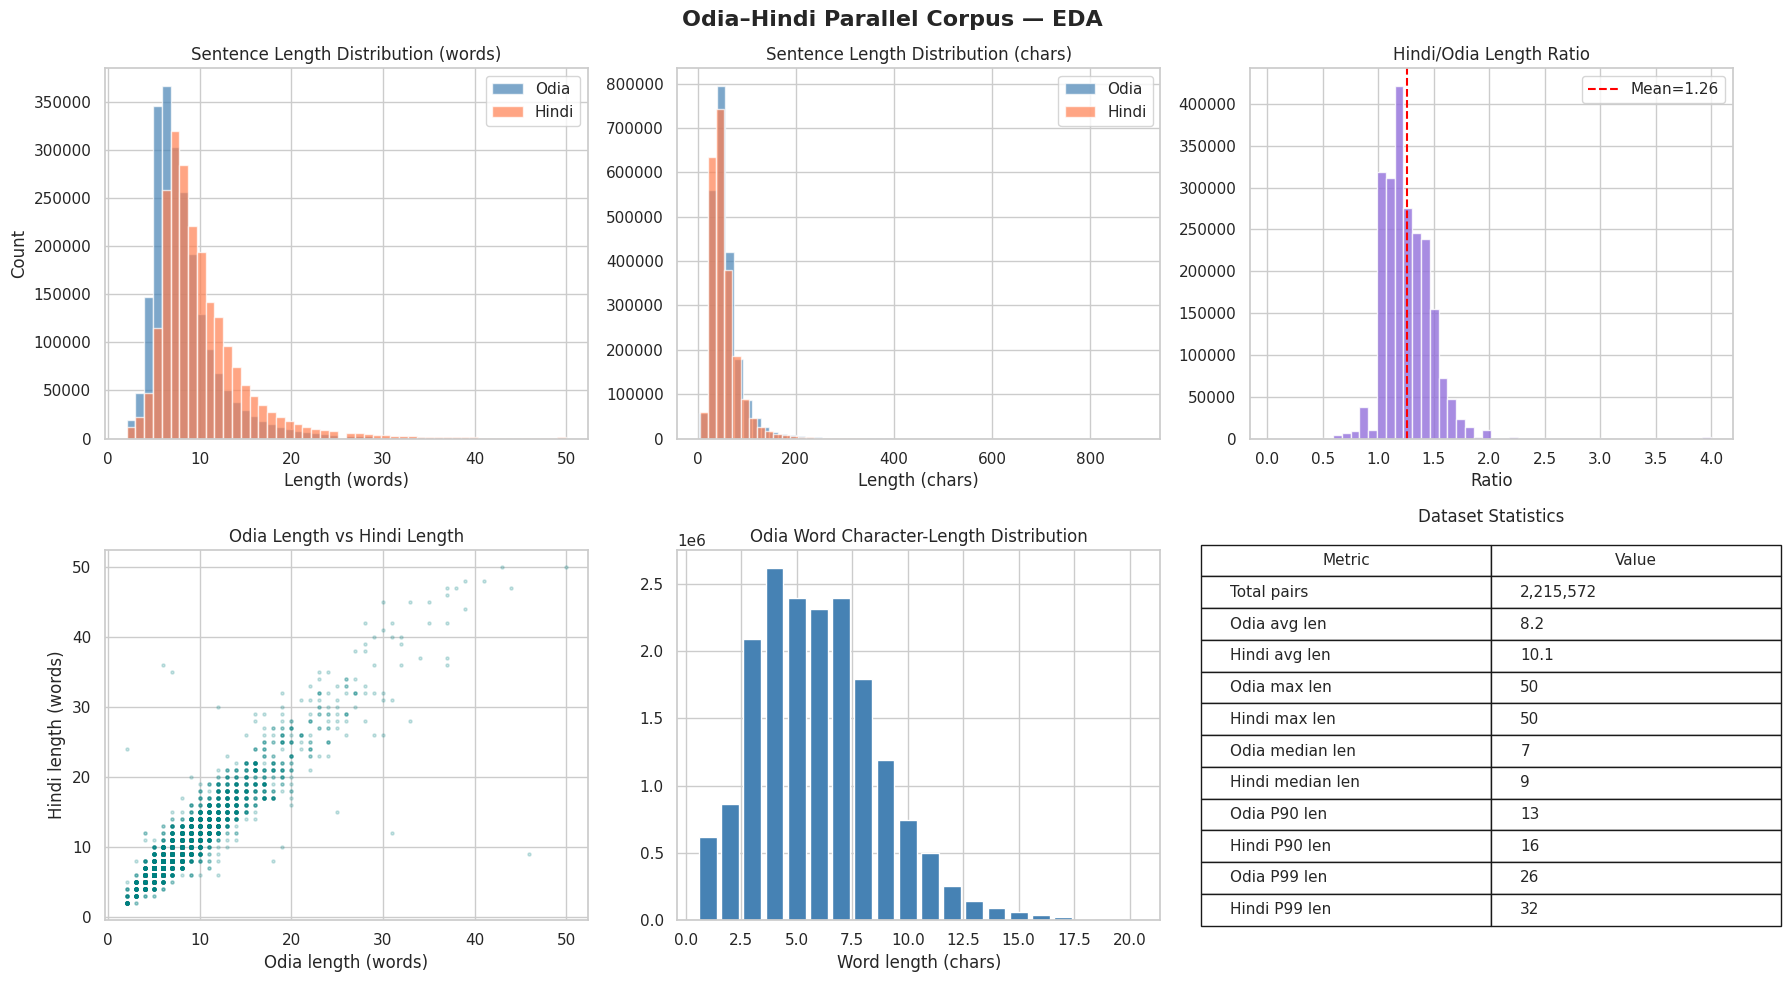

✅ EDA saved

Dataset size : 2,215,572
Odia   P50 / P90 / P99 word length : 7 / 13 / 26
Hindi  P50 / P90 / P99 word length : 9 / 16 / 32


In [ ]:
def plot_eda(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Odia–Hindi Parallel Corpus — EDA', fontsize=16, fontweight='bold')

    axes[0, 0].hist(df['odia_len'],  bins=50, color='steelblue', alpha=0.7, label='Odia')
    axes[0, 0].hist(df['hindi_len'], bins=50, color='coral',     alpha=0.7, label='Hindi')
    axes[0, 0].set_title('Sentence Length Distribution (words)')
    axes[0, 0].set_xlabel('Length (words)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    df_chars = df.copy()
    df_chars['odia_chars']  = df['odia'].str.len()
    df_chars['hindi_chars'] = df['hindi'].str.len()
    axes[0, 1].hist(df_chars['odia_chars'],  bins=50, color='steelblue', alpha=0.7, label='Odia')
    axes[0, 1].hist(df_chars['hindi_chars'], bins=50, color='coral',     alpha=0.7, label='Hindi')
    axes[0, 1].set_title('Sentence Length Distribution (chars)')
    axes[0, 1].set_xlabel('Length (chars)')
    axes[0, 1].legend()

    ratio = df['hindi_len'] / (df['odia_len'] + 1e-9)
    axes[0, 2].hist(ratio.clip(0, 4), bins=50, color='mediumpurple', alpha=0.8)
    axes[0, 2].axvline(ratio.mean(), color='red', linestyle='--', label=f'Mean={ratio.mean():.2f}')
    axes[0, 2].set_title('Hindi/Odia Length Ratio')
    axes[0, 2].set_xlabel('Ratio')
    axes[0, 2].legend()

    sample = df.sample(min(5000, len(df)), random_state=42)
    axes[1, 0].scatter(sample['odia_len'], sample['hindi_len'],
                       alpha=0.2, s=5, color='teal')
    axes[1, 0].set_title('Odia Length vs Hindi Length')
    axes[1, 0].set_xlabel('Odia length (words)')
    axes[1, 0].set_ylabel('Hindi length (words)')

    odia_wl        = df['odia'].str.split().explode().str.len()
    odia_wl_counts = odia_wl.value_counts().sort_index().head(20)
    axes[1, 1].bar(odia_wl_counts.index, odia_wl_counts.values, color='steelblue')
    axes[1, 1].set_title('Odia Word Character-Length Distribution')
    axes[1, 1].set_xlabel('Word length (chars)')

    axes[1, 2].axis('off')
    stats = [
        ['Total pairs',      f"{len(df):,}"],
        ['Odia avg len',     f"{df['odia_len'].mean():.1f}"],
        ['Hindi avg len',    f"{df['hindi_len'].mean():.1f}"],
        ['Odia max len',     f"{df['odia_len'].max()}"],
        ['Hindi max len',    f"{df['hindi_len'].max()}"],
        ['Odia median len',  f"{df['odia_len'].median():.0f}"],
        ['Hindi median len', f"{df['hindi_len'].median():.0f}"],
        ['Odia P90 len',     f"{df['odia_len'].quantile(0.9):.0f}"],
        ['Hindi P90 len',    f"{df['hindi_len'].quantile(0.9):.0f}"],
        ['Odia P99 len',     f"{df['odia_len'].quantile(0.99):.0f}"],
        ['Hindi P99 len',    f"{df['hindi_len'].quantile(0.99):.0f}"],
    ]
    table = axes[1, 2].table(
        cellText=stats, colLabels=['Metric', 'Value'],
        loc='center', cellLoc='left'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)
    axes[1, 2].set_title('Dataset Statistics', pad=20)

    plt.tight_layout()
    plt.savefig(f'{Config.OUTPUT_DIR}/eda_plots.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ EDA saved')


plot_eda(df)

# ── Percentile breakdown (useful for tuning MAX_LEN) ─────────────────────────
print(f'\nDataset size : {len(df):,}')
print(f'Odia   P50 / P90 / P99 word length : '
      f'{df["odia_len"].quantile(.50):.0f} / '
      f'{df["odia_len"].quantile(.90):.0f} / '
      f'{df["odia_len"].quantile(.99):.0f}')
print(f'Hindi  P50 / P90 / P99 word length : '
      f'{df["hindi_len"].quantile(.50):.0f} / '
      f'{df["hindi_len"].quantile(.90):.0f} / '
      f'{df["hindi_len"].quantile(.99):.0f}')

## Cell 8 — Morphessor


In [ ]:
import os
import gc
import sys
import subprocess
import pickle
from collections import Counter
from functools import lru_cache
from typing import List

import morfessor
from tqdm.auto import tqdm

MORPH_DIR = getattr(Config, 'MORPH_DIR', '/kaggle/working/morph_models')
os.makedirs(MORPH_DIR, exist_ok=True)

class MorphSegmenter:

    _STRIP = '.,?!();:\"\''

    def __init__(self,
                 lang: str,
                 morph_dir: str,
                 finish_threshold: float | None = None):
        self.lang              = lang
        self.model_path        = os.path.join(morph_dir, f'morfessor_{lang}.bin')
        self.cache_path        = os.path.join(morph_dir, f'morph_cache_{lang}.pkl')
        self._model            = None
        self._trained          = False
        self._finish_threshold = finish_threshold or (
            0.01 if lang == 'or' else 0.005
        )

    def train(self, sentences: List[str]) -> None:
        print(f'\n🔬 Training Morfessor [{self.lang}]  '
            f'(finish_threshold={self._finish_threshold})...')
        print(f'   Training on {len(sentences):,} sentences')

        _table = str.maketrans('', '', self._STRIP)
        word_counts: Counter = Counter()

        for sent in tqdm(sentences,
                         desc=f'  Counting [{self.lang}]',
                         leave=False,
                         miniters=50_000):
            for tok in sent.split():
                w = tok.translate(_table)
                if len(w) >= 2:
                    word_counts[w] += 1

        corpus_list = [
            (cnt, word)
            for word, cnt in word_counts.items()
            if cnt >= 2
        ]
        print(f'   Total unique tokens  : {len(word_counts):,}')
        print(f'   Tokens freq ≥ 2      : {len(corpus_list):,}')

        io           = morfessor.MorfessorIO()
        self._model  = morfessor.BaselineModel()

        self._model.train_batch(
            corpus_list,
            finish_threshold=self._finish_threshold,
        )
        self._trained = True

        io.write_binary_model_file(self.model_path, self._model)
        print(f'   ✅ Model saved → {self.model_path}')

        self._print_samples(word_counts)

    def load(self) -> bool:
        if os.path.exists(self.model_path):
            io            = morfessor.MorfessorIO()
            self._model   = io.read_binary_model_file(self.model_path)
            self._trained = True
            print(f'   📦 Loaded Morfessor model : {self.model_path}')
            return True
        return False

    @lru_cache(maxsize=262_144)
    def segment_word(self, word: str) -> str:

        if not self._trained or self._model is None or len(word) <= 2:
            return word
        try:
            morphs, _ = self._model.viterbi_segment(word)
            return ' '.join(morphs) if morphs else word
        except Exception:
            return word

    def segment_sentence(self, sentence: str) -> str:
        """Segment every token in a sentence string."""
        if not self._trained or self._model is None:
            return sentence
        _table = str.maketrans('', '', self._STRIP)
        parts  = []
        for tok in sentence.split():
            clean = tok.translate(_table)
            seg   = self.segment_word(clean) if len(clean) >= 2 else clean
            # Re-attach trailing punctuation that was stripped
            suffix = tok[len(clean):]       # chars removed from right
            parts.append(seg + suffix)
        return ' '.join(parts)

    def segment_corpus(self,
                       sentences: List[str],
                       desc: str = '') -> List[str]:
        """
        Segment a full list of sentences efficiently.
        Uses a persistent word-level cache on disk:
          • First run  → segment everything, save cache
          • Next run   → load cache, only segment new words
        """
        disk_cache: dict = {}
        if os.path.exists(self.cache_path):
            print(f'   📂 Loading word cache: {self.cache_path}')
            with open(self.cache_path, 'rb') as f:
                disk_cache = pickle.load(f)
            print(f'      {len(disk_cache):,} entries loaded')

        _table  = str.maketrans('', '', self._STRIP)
        results = []
        new_entries = 0

        for sent in tqdm(sentences, desc=desc or f'  Segmenting [{self.lang}]',
                         miniters=50_000):
            parts = []
            for tok in sent.split():
                clean  = tok.translate(_table)
                suffix = tok[len(clean):]
                if len(clean) <= 2:
                    parts.append(tok)
                    continue
                if clean in disk_cache:
                    seg = disk_cache[clean]
                else:
                    seg = self.segment_word(clean)
                    disk_cache[clean] = seg
                    new_entries      += 1
                parts.append(seg + suffix)
            results.append(' '.join(parts))

        if new_entries > 0:
            print(f'   💾 Saving updated cache '
                  f'({new_entries:,} new entries) → {self.cache_path}')
            with open(self.cache_path, 'wb') as f:
                pickle.dump(disk_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

        return results

    def _print_samples(self, word_counts: Counter, n: int = 10) -> None:
        """Print segmentation examples, skipping words that fail."""
        print(f'\n   📋 Sample segmentations [{self.lang}]:')
        candidates = [
            w for w, _ in word_counts.most_common(500)
            if len(w) >= 4
        ][:n * 3] 

        shown = 0
        for w in candidates:
            if shown >= n:
                break
            try:
                morphs, _ = self._model.viterbi_segment(w)
                seg        = ' + '.join(morphs)
                print(f'     {w:<30} → {seg}')
                shown += 1
            except Exception as e:

                continue

        if shown == 0:
            print('     ⚠️  No successful segmentations in sample. '
                  'Check that Morfessor was installed with Unicode support.')


odia_morph  = MorphSegmenter(lang='or', morph_dir=MORPH_DIR, finish_threshold=0.01)
hindi_morph = MorphSegmenter(lang='hi', morph_dir=MORPH_DIR, finish_threshold=0.005)

train_size = min(len(df), Config.MORPH_TRAIN_SIZE)
print(f'   Morfessor training size: {train_size:,} sentences')

if not odia_morph.load():
    odia_morph.train(df['odia'].tolist()[:train_size])

gc.collect()

if not hindi_morph.load():
    hindi_morph.train(df['hindi'].tolist()[:train_size])

gc.collect()

if Config.USE_MORPH:
    print('\n⚙️  Applying morphological segmentation to full corpus...')
    print('   (Uses persistent disk cache — fast on re-runs)\n')

    odia_segs  = odia_morph.segment_corpus(
        df['odia'].tolist(),
        desc='  Segmenting Odia '
    )
    hindi_segs = hindi_morph.segment_corpus(
        df['hindi'].tolist(),
        desc='  Segmenting Hindi'
    )

    df['odia_morph']  = odia_segs
    df['hindi_morph'] = hindi_segs
else:
    df['odia_morph']  = df['odia']
    df['hindi_morph'] = df['hindi']

df['odia_morph_len']  = df['odia_morph'].str.split().str.len()
df['hindi_morph_len'] = df['hindi_morph'].str.split().str.len()

before = len(df)
df = df[
    (df['odia_morph_len']  <= Config.MAX_LEN) &
    (df['hindi_morph_len'] <= Config.MAX_LEN)
].reset_index(drop=True)

print(f'\n   Filtered {before - len(df):,} rows with morpheme length > {Config.MAX_LEN}')
print(f'   Final dataset : {len(df):,} pairs')

print('\n📋 Segmentation examples:')
for i in range(min(5, len(df))):
    print(f'  [{i+1}] Odia  raw  : {df["odia"].iloc[i]}')
    print(f'      Odia  morph: {df["odia_morph"].iloc[i]}')
    print(f'      Hindi raw  : {df["hindi"].iloc[i]}')
    print(f'      Hindi morph: {df["hindi_morph"].iloc[i]}')
    print()

   Morfessor training size: 600,000 sentences

🔬 Training Morfessor [or]  (finish_threshold=0.01)...
   Training on 600,000 sentences


  Counting [or]:   0%|          | 0/600000 [00:00<?, ?it/s]

- |#                                                  | 0 Elapsed Time: 0:00:00
- |#                                                  | 0 Elapsed Time: 0:00:00


   Total unique tokens  : 251,816
   Tokens freq ≥ 2      : 124,147
   ✅ Model saved → /kaggle/working/morph_models/morfessor_or.bin

   📋 Sample segmentations [or]:
     ⚠️  No successful segmentations in sample. Check that Morfessor was installed with Unicode support.

🔬 Training Morfessor [hi]  (finish_threshold=0.005)...
   Training on 600,000 sentences


  Counting [hi]:   0%|          | 0/600000 [00:00<?, ?it/s]

...

   Total unique tokens  : 163,369
   Tokens freq ≥ 2      : 90,117
   ✅ Model saved → /kaggle/working/morph_models/morfessor_hi.bin

   📋 Sample segmentations [hi]:
     ⚠️  No successful segmentations in sample. Check that Morfessor was installed with Unicode support.

⚙️  Applying morphological segmentation to full corpus...
   (Uses persistent disk cache — fast on re-runs)



  Segmenting Odia :   0%|          | 0/2215572 [00:00<?, ?it/s]

   💾 Saving updated cache (480,875 new entries) → /kaggle/working/morph_models/morph_cache_or.pkl


  Segmenting Hindi:   0%|          | 0/2215572 [00:00<?, ?it/s]

   💾 Saving updated cache (302,640 new entries) → /kaggle/working/morph_models/morph_cache_hi.pkl

   Filtered 0 rows with morpheme length > 50
   Final dataset : 2,215,572 pairs

📋 Segmentation examples:
  [1] Odia  raw  : ବକ୍ରେଶ୍ୱରର ଉଚ୍ଚତା କେତେ?
      Odia  morph: ବକ୍ରେଶ୍ୱରର ଉଚ୍ଚତା କେତେ?
      Hindi raw  : बक्रेश्वर की ऊँचाई क्या है?
      Hindi morph: बक्रेश्वर की ऊँचाई क्या है?

  [2] Odia  raw  : ସେ ନେଟଫ୍ଲିକ୍ସ ସିରିଜ୍ 'ବ୍ରିଜରଟନ୍' ରେ ତାଙ୍କ ଭୂମିକା ପାଇଁ ସ୍ୱୀକୃତି ହାସଲ କରିଥିଲେ
      Odia  morph: ସେ ନେଟଫ୍ଲିକ୍ସ ସିରିଜ୍ ବ୍ରିଜରଟନ୍୍' ରେ ତାଙ୍କ ଭୂମିକା ପାଇଁ ସ୍ୱୀକୃତି ହାସଲ କରିଥିଲେ
      Hindi raw  : उन्होंने नेटफ्लिक्स श्रृंखला 'ब्रिजरटन' में अपनी भूमिका के लिए पहचान हासिल की
      Hindi morph: उन्होंने नेटफ्लिक्स श्रृंखला ब्रिजरटनन' में अपनी भूमिका के लिए पहचान हासिल की

  [3] Odia  raw  : ଉଦ୍ଭିଦ ବିଜ୍ଞାନରେ ଉଦ୍ଭିଦ ଶରୀର ବିଜ୍ଞାନରେ ବିଶେଷଜ୍ଞ, ଏବଂ
      Odia  morph: ଉଦ୍ଭିଦ ବିଜ୍ଞାନରେ ଉଦ୍ଭିଦ ଶରୀର ବିଜ୍ଞାନରେ ବିଶେଷଜ୍ଞ, ଏବଂ
      Hindi raw  : वनस्पति विज्ञान में विशेषज्ञता प्राप्त पादप शरीर विज्ञान, और ए बी


## Cell 9 — Vocabulary & Tokenizer

In [ ]:
class Vocabulary:
    PAD_IDX = 0
    SOS_IDX = 1
    EOS_IDX = 2
    UNK_IDX = 3

    def __init__(self, name: str):
        self.name     = name
        self.token2id : Dict[str, int] = {
            Config.PAD: self.PAD_IDX,
            Config.SOS: self.SOS_IDX,
            Config.EOS: self.EOS_IDX,
            Config.UNK: self.UNK_IDX,
        }
        self.id2token : Dict[int, str] = {v: k for k, v in self.token2id.items()}
        self.freq     : Counter = Counter()

    @property
    def size(self) -> int:
        return len(self.token2id)

    def build(self, sentences: List[str], max_size: int, min_freq: int) -> None:
        """Build vocabulary from Morfessor-segmented sentences."""
        for sent in sentences:
            for tok in sent.split():
                self.freq[tok] += 1

        sorted_toks = sorted(
            [(cnt, tok) for tok, cnt in self.freq.items() if cnt >= min_freq],
            reverse=True
        )

        capacity = max_size - 4
        for i, (cnt, tok) in enumerate(sorted_toks[:capacity]):
            idx = i + 4
            self.token2id[tok] = idx
            self.id2token[idx] = tok

        print(f'  [{self.name}] Vocab size      : {self.size:,}')
        print(f'  [{self.name}] Unique tokens   : {len(self.freq):,}')
        print(f'  [{self.name}] min_freq filter : {min_freq}')

    def encode(self, sentence: str, add_special: bool = True) -> List[int]:
        ids = [self.token2id.get(tok, self.UNK_IDX) for tok in sentence.split()]
        if add_special:
            ids = [self.SOS_IDX] + ids + [self.EOS_IDX]
        return ids

    def decode(self, ids: List[int], skip_special: bool = True) -> str:
        skip = {self.PAD_IDX, self.SOS_IDX, self.EOS_IDX} if skip_special else set()
        tokens = [self.id2token.get(i, Config.UNK) for i in ids if i not in skip]
        return ' '.join(tokens)

    def save(self, path: str) -> None:
        with open(path, 'wb') as f:
            pickle.dump({
                'token2id': self.token2id,
                'id2token': self.id2token,
                'freq'    : self.freq,
                'name'    : self.name
            }, f)
        print(f'  [{self.name}] Saved → {path}')

    @classmethod
    def load(cls, path: str) -> 'Vocabulary':
        with open(path, 'rb') as f:
            data = pickle.load(f)
        v           = cls(data['name'])
        v.token2id  = data['token2id']
        v.id2token  = data['id2token']
        v.freq      = data['freq']
        return v


print('📚 Building vocabularies from Morfessor-segmented corpus...')
src_vocab = Vocabulary('Odia')
tgt_vocab = Vocabulary('Hindi')

src_vocab.build(df['odia_morph'].tolist(),
                max_size=Config.SRC_VOCAB_SIZE, min_freq=Config.MIN_FREQ)
tgt_vocab.build(df['hindi_morph'].tolist(),
                max_size=Config.TGT_VOCAB_SIZE, min_freq=Config.MIN_FREQ)

src_vocab.save(f'{Config.MODEL_DIR}/vocab_odia.pkl')
tgt_vocab.save(f'{Config.MODEL_DIR}/vocab_hindi.pkl')
print('\n✅ Vocabularies saved!')

def vocab_coverage(sentences: List[str], vocab: Vocabulary) -> float:
    total, covered = 0, 0
    for sent in sentences:
        for tok in sent.split():
            total   += 1
            if tok in vocab.token2id:
                covered += 1
    return covered / total if total > 0 else 0.0

odia_cov  = vocab_coverage(df['odia_morph'].tolist(),  src_vocab)
hindi_cov = vocab_coverage(df['hindi_morph'].tolist(), tgt_vocab)

print(f'\n📊 Vocabulary Coverage:')
print(f'   Odia  morpheme coverage: {odia_cov*100:.2f}%')
print(f'   Hindi morpheme coverage: {hindi_cov*100:.2f}%')

if odia_cov < 0.95:
    print('   ⚠️  Odia coverage < 95% — lower MIN_FREQ or increase SRC_VOCAB_SIZE')
if hindi_cov < 0.95:
    print('   ⚠️  Hindi coverage < 95% — lower MIN_FREQ or increase TGT_VOCAB_SIZE')
if odia_cov >= 0.98 and hindi_cov >= 0.98:
    print('   ✅ Excellent coverage — <unk> tokens will be rare')

📚 Building vocabularies from Morfessor-segmented corpus...
  [Odia] Vocab size      : 40,000
  [Odia] Unique tokens   : 589,282
  [Odia] min_freq filter : 2
  [Hindi] Vocab size      : 40,000
  [Hindi] Unique tokens   : 392,561
  [Hindi] min_freq filter : 2
  [Odia] Saved → /kaggle/working/models/vocab_odia.pkl
  [Hindi] Saved → /kaggle/working/models/vocab_hindi.pkl

✅ Vocabularies saved!

📊 Vocabulary Coverage:
   Odia  morpheme coverage: 90.17%
   Hindi morpheme coverage: 94.77%
   ⚠️  Odia coverage < 95% — lower MIN_FREQ or increase SRC_VOCAB_SIZE
   ⚠️  Hindi coverage < 95% — lower MIN_FREQ or increase TGT_VOCAB_SIZE


## Cell 10 — Dataset & DataLoaders

In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, src_vocab: Vocabulary,
                 tgt_vocab: Vocabulary, max_len: int = Config.MAX_LEN):
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len   = max_len
        self.src_data  = [
            src_vocab.encode(s, add_special=True)[:max_len + 2]
            for s in df['odia_morph'].tolist()
        ]
        self.tgt_data  = [
            tgt_vocab.encode(s, add_special=True)[:max_len + 2]
            for s in df['hindi_morph'].tolist()
        ]

    def __len__(self): return len(self.src_data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.src_data[idx], dtype=torch.long),
            torch.tensor(self.tgt_data[idx], dtype=torch.long),
        )


class BucketSampler(Sampler):
    def __init__(self, lengths: List[int], batch_size: int, shuffle: bool = True,
                 bucket_width: int = 20):
        self.lengths     = lengths
        self.batch_size  = batch_size
        self.shuffle     = shuffle
        self.bucket_width= bucket_width

    def __iter__(self):
        buckets: Dict[int, List[int]] = {}
        for i, l in enumerate(self.lengths):
            bucket = l // self.bucket_width
            if bucket not in buckets: buckets[bucket] = []
            buckets[bucket].append(i)

        all_batches = []
        for bucket_idxs in buckets.values():
            if self.shuffle:
                random.shuffle(bucket_idxs)
            for start in range(0, len(bucket_idxs), self.batch_size):
                all_batches.append(bucket_idxs[start: start + self.batch_size])

        if self.shuffle:
            random.shuffle(all_batches)

        for batch in all_batches:
            yield from batch

    def __len__(self):
        return len(self.lengths)


def collate_fn(batch, pad_idx: int = Vocabulary.PAD_IDX):
    srcs, tgts = zip(*batch)
    src_padded = pad_sequence(srcs, batch_first=True, padding_value=pad_idx)
    tgt_padded = pad_sequence(tgts, batch_first=True, padding_value=pad_idx)
    return src_padded, tgt_padded


df_train_val, df_test = train_test_split(
    df, test_size=Config.TEST_RATIO, random_state=SEED, shuffle=True
)
val_frac = Config.VAL_RATIO / (1 - Config.TEST_RATIO)
df_train, df_val = train_test_split(df_train_val, test_size=val_frac, random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'📊 Data splits:')
print(f'   Train: {len(df_train):>10,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'   Val  : {len(df_val):>10,} ({len(df_val)/len(df)*100:.1f}%)')
print(f'   Test : {len(df_test):>10,} ({len(df_test)/len(df)*100:.1f}%)')

train_dataset = TranslationDataset(df_train, src_vocab, tgt_vocab)
val_dataset   = TranslationDataset(df_val,   src_vocab, tgt_vocab)
test_dataset  = TranslationDataset(df_test,  src_vocab, tgt_vocab)

_collate = lambda b: collate_fn(b, pad_idx=Vocabulary.PAD_IDX)

train_src_lengths = [len(x) for x in train_dataset.src_data]
train_sampler = BucketSampler(
    train_src_lengths, batch_size=Config.BATCH_SIZE, shuffle=True, bucket_width=20
)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    sampler=train_sampler,
    collate_fn=_collate,
    num_workers=2,
    pin_memory=(DEVICE.type == 'cuda'),
    drop_last=False,
)
val_loader = DataLoader(
    val_dataset, batch_size=Config.BATCH_SIZE * 2,
    shuffle=False, collate_fn=_collate,
    num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
)
test_loader = DataLoader(
    test_dataset, batch_size=Config.BATCH_SIZE * 2,
    shuffle=False, collate_fn=_collate,
    num_workers=2, pin_memory=(DEVICE.type == 'cuda'),
)

print(f'\n✅ DataLoaders created:')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val   batches: {len(val_loader)}')
print(f'   Test  batches: {len(test_loader)}')
_src, _tgt = next(iter(train_loader))
print(f'   Batch src shape: {_src.shape}  tgt shape: {_tgt.shape}')


📊 Data splits:
   Train:  1,772,456 (80.0%)
   Val  :    221,558 (10.0%)
   Test :    221,558 (10.0%)

✅ DataLoaders created:
   Train batches: 27695
   Val   batches: 1731
   Test  batches: 1731
   Batch src shape: torch.Size([64, 19])  tgt shape: torch.Size([64, 24])


## Cell 11 — Transformer Architecture

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 1024):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position  = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term  = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class TranslatorTransformer(nn.Module):
    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model:        int   = Config.D_MODEL,
        nhead:          int   = Config.N_HEADS,
        num_enc_layers: int   = Config.N_ENC_LAYERS,
        num_dec_layers: int   = Config.N_DEC_LAYERS,
        dim_feedforward:int   = Config.D_FF,
        dropout:        float = Config.DROPOUT,
        max_pos_enc:    int   = Config.MAX_POS_ENC,
        pad_idx:        int   = Vocabulary.PAD_IDX,
    ):
        super().__init__()
        self.d_model  = d_model
        self.pad_idx  = pad_idx

        self.src_embed = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, dropout, max_pos_enc)

        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_enc_layers,
            num_decoder_layers=num_dec_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True, # Pre-LayerNorm
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'embed' in name:
                nn.init.normal_(p, mean=0.0, std=0.02)
            elif p.dim() > 1:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
        with torch.no_grad():
            self.src_embed.weight[self.pad_idx].fill_(0)
            self.tgt_embed.weight[self.pad_idx].fill_(0)

    def make_src_padding_mask(self, src): return src == self.pad_idx
    def make_tgt_padding_mask(self, tgt): return tgt == self.pad_idx

    def make_causal_mask(self, tgt_len: int, device: torch.device) -> torch.Tensor:
        return torch.triu(torch.ones(tgt_len, tgt_len, device=device), diagonal=1).bool()

    def encode(self, src: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        src_pad_mask = self.make_src_padding_mask(src)
        src_emb = self.pos_enc(self.src_embed(src) * math.sqrt(self.d_model))
        memory  = self.transformer.encoder(src_emb, src_key_padding_mask=src_pad_mask)
        return memory, src_pad_mask

    def decode(self, tgt: torch.Tensor, memory: torch.Tensor,
               src_pad_mask: torch.Tensor) -> torch.Tensor:
        tgt_len      = tgt.size(1)
        causal_mask  = self.make_causal_mask(tgt_len, tgt.device)
        tgt_pad_mask = self.make_tgt_padding_mask(tgt)
        tgt_emb      = self.pos_enc(self.tgt_embed(tgt) * math.sqrt(self.d_model))
        out = self.transformer.decoder(
            tgt_emb, memory,
            tgt_mask=causal_mask,
            tgt_key_padding_mask=tgt_pad_mask,
            memory_key_padding_mask=src_pad_mask,
        )
        return self.fc_out(out)  # (B, T, tgt_vocab)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor) -> torch.Tensor:
        memory, src_pad_mask = self.encode(src)
        return self.decode(tgt[:, :-1], memory, src_pad_mask)  # (B, T-1, V)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

model = TranslatorTransformer(
    src_vocab_size=src_vocab.size,
    tgt_vocab_size=tgt_vocab.size,
    d_model       =Config.D_MODEL,
    nhead         =Config.N_HEADS,
    num_enc_layers=Config.N_ENC_LAYERS,
    num_dec_layers=Config.N_DEC_LAYERS,
    dim_feedforward=Config.D_FF,
    dropout       =Config.DROPOUT,
    max_pos_enc   =Config.MAX_POS_ENC,
    pad_idx       =Vocabulary.PAD_IDX,
).to(DEVICE)

n_params = model.count_parameters()
print(f'\n🏗️  Model Architecture Summary')
print(f'   Parameters (trainable): {n_params:,} ({n_params/1e6:.1f}M)')
print(f'   Source vocab size: {src_vocab.size:,}')
print(f'   Target vocab size: {tgt_vocab.size:,}')
print(f'   d_model={Config.D_MODEL}, heads={Config.N_HEADS}, '
      f'enc_layers={Config.N_ENC_LAYERS}, dec_layers={Config.N_DEC_LAYERS}, '
      f'd_ff={Config.D_FF}')

_src, _tgt = next(iter(train_loader))
_src, _tgt = _src.to(DEVICE), _tgt.to(DEVICE)
with torch.no_grad():
    _logits = model(_src, _tgt)
print(f'   Forward pass OK: src{list(_src.shape)} → logits{list(_logits.shape)}')

del _src, _tgt, _logits
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



🏗️  Model Architecture Summary
   Parameters (trainable): 34,714,688 (34.7M)
   Source vocab size: 40,000
   Target vocab size: 40,000
   d_model=256, heads=8, enc_layers=3, dec_layers=3, d_ff=512
   Forward pass OK: src[64, 19] → logits[64, 22, 40000]


## Cell 12 — Loss, Optimizer, Scheduler & Early Stopping

In [ ]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, pad_idx, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.pad_idx    = pad_idx
        self.smoothing  = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        B_T, V     = logits.shape
        log_probs  = F.log_softmax(logits, dim=-1)
        smooth_val = self.smoothing / (V - 2)
        with torch.no_grad():
            smooth_dist = torch.full_like(log_probs, smooth_val)
            smooth_dist.scatter_(1, targets.unsqueeze(1), self.confidence)
            smooth_dist[:, self.pad_idx] = 0.0
        non_pad_mask = (targets != self.pad_idx).float()
        loss = -(smooth_dist * log_probs).sum(dim=-1)
        return (loss * non_pad_mask).sum() / non_pad_mask.sum().clamp(min=1)


class WarmupScheduler:
    def __init__(self, optimizer, d_model, warmup_steps):
        self.optimizer    = optimizer
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        self._step        = 0

    def step(self):
        self._step += 1
        lr = (self.d_model ** -0.5) * min(
            self._step ** -0.5, self._step * self.warmup_steps ** -1.5
        )
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

    def get_last_lr(self) -> float:
        if self._step == 0:
            return 0.0
        return (self.d_model ** -0.5) * min(
            self._step ** -0.5, self._step * self.warmup_steps ** -1.5
        )


class EarlyStopping:
    def __init__(self, patience, min_delta, save_path):
        self.patience  = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.best_loss = float('inf')
        self.counter   = 0
        self.triggered = False

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.save_path)
            return False
        self.counter += 1
        if self.counter >= self.patience:
            self.triggered = True
            return True
        return False


class CheckpointManager:
    def __init__(self, ckpt_dir, keep_last_n=3):
        self.ckpt_dir    = ckpt_dir
        self.keep_last_n = keep_last_n
        self.ckpt_list   = []

    def save(self, epoch, model, optimizer, scheduler, metrics):
        path = os.path.join(self.ckpt_dir, f'ckpt_epoch_{epoch:03d}.pt')
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_step': scheduler._step, 'metrics': metrics,
        }, path)
        self.ckpt_list.append(path)
        while len(self.ckpt_list) > self.keep_last_n:
            old = self.ckpt_list.pop(0)
            if os.path.exists(old): os.remove(old)
        return path

    def load_latest(self, model, optimizer=None):
        ckpts = sorted(Path(self.ckpt_dir).glob('ckpt_epoch_*.pt'))
        if not ckpts:
            print('  No checkpoints found.')
            return {}
        path = str(ckpts[-1])
        ckpt = torch.load(path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        if optimizer:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        print(f'  ✅ Loaded checkpoint: {path} (epoch {ckpt["epoch"]})')
        return ckpt


criterion = LabelSmoothingLoss(
    vocab_size=tgt_vocab.size, pad_idx=Vocabulary.PAD_IDX,
    smoothing=Config.LABEL_SMOOTH,
)
optimizer = torch.optim.Adam(
    model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9, weight_decay=1e-4
)
scheduler    = WarmupScheduler(optimizer, Config.D_MODEL, Config.WARMUP_STEPS)
early_stopper= EarlyStopping(Config.PATIENCE, Config.MIN_DELTA,
                              f'{Config.MODEL_DIR}/best_model.pt')
ckpt_manager = CheckpointManager(Config.CKPT_DIR, Config.KEEP_LAST_N)
scaler = GradScaler('cuda', enabled=Config.USE_AMP)

print('✅ Training components ready!')
print(f'   AMP (mixed precision) : {Config.USE_AMP}')
print(f'   Warmup steps          : {Config.WARMUP_STEPS}')
print(f'   Max epochs            : {Config.MAX_EPOCHS}')
print(f'   Patience              : {Config.PATIENCE}')
print(f'   Grad accumulation     : {Config.ACCUMULATE_GRAD}  '
      f'(effective batch = {Config.BATCH_SIZE * Config.ACCUMULATE_GRAD})')

✅ Training components ready!
   AMP (mixed precision) : True
   Warmup steps          : 4000
   Max epochs            : 20
   Patience              : 5
   Grad accumulation     : 4  (effective batch = 256)


## Cell 13 — Training Loop (with Checkpointing & Resume Support)

In [ ]:
def run_epoch_train(model, loader, criterion, optimizer, scheduler, scaler,
                    device, grad_clip, accum_steps) -> Tuple[float, float]:
    model.train()
    total_loss = total_tokens = 0
    optimizer.zero_grad()

    pbar = tqdm(loader, desc='  Train', leave=False)
    for step, (src, tgt) in enumerate(pbar, 1):
        src, tgt = src.to(device, non_blocking=True), tgt.to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=Config.USE_AMP):
            logits       = model(src, tgt)
            tgt_out      = tgt[:, 1:]
            logits_flat  = logits.reshape(-1, logits.size(-1))
            targets_flat = tgt_out.reshape(-1)
            loss = criterion(logits_flat, targets_flat)

        scaler.scale(loss).backward()

        n_tokens      = (targets_flat != Vocabulary.PAD_IDX).sum().item()
        total_loss   += loss.item() * accum_steps * n_tokens
        total_tokens += n_tokens

        if step % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        pbar.set_postfix(
            loss=f'{loss.item()*accum_steps:.4f}',
            lr=f'{scheduler.get_last_lr():.2e}',
        )

    if step % accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, math.exp(min(avg_loss, 20))


@torch.no_grad()
def run_epoch_eval(model, loader, criterion, device) -> Tuple[float, float]:
    model.eval()
    total_loss = total_tokens = 0
    for src, tgt in tqdm(loader, desc='  Val  ', leave=False):
        src, tgt = src.to(device, non_blocking=True), tgt.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=Config.USE_AMP):
            logits       = model(src, tgt)
            tgt_out      = tgt[:, 1:]
            logits_flat  = logits.reshape(-1, logits.size(-1))
            targets_flat = tgt_out.reshape(-1)
            loss = criterion(logits_flat, targets_flat)
        n_tokens      = (targets_flat != Vocabulary.PAD_IDX).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens
    avg_loss = total_loss / max(total_tokens, 1)
    return avg_loss, math.exp(min(avg_loss, 20))


history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': [], 'lr': []}

START_EPOCH = 1
ckpt = ckpt_manager.load_latest(model, optimizer)
if ckpt:
    START_EPOCH = ckpt['epoch'] + 1
    scheduler._step = ckpt['scheduler_step']
    history_path = f'{Config.OUTPUT_DIR}/history.json'
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        print(f'   📂 History restored ({len(history["train_loss"])} epochs)')
    print(f'▶️  Resuming from epoch {START_EPOCH}')
else:
    print('▶️  Starting fresh training')

print(f'\n🚀 Training: epoch {START_EPOCH} → {Config.MAX_EPOCHS}')
print(f'   Patience={Config.PATIENCE} | grad_clip={Config.GRAD_CLIP} | '
      f'accum={Config.ACCUMULATE_GRAD} | AMP={Config.USE_AMP}')

for epoch in range(START_EPOCH, Config.MAX_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_ppl = run_epoch_train(
        model, train_loader, criterion, optimizer, scheduler, scaler,
        DEVICE, Config.GRAD_CLIP, Config.ACCUMULATE_GRAD,
    )
    val_loss, val_ppl = run_epoch_eval(model, val_loader, criterion, DEVICE)

    elapsed = time.time() - t0
    is_best = val_loss < early_stopper.best_loss
    star    = '⭐' if is_best else '  '

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['lr'].append(scheduler.get_last_lr())

    print(f'Epoch [{epoch:03d}/{Config.MAX_EPOCHS}] {star} | '
          f'Train Loss: {train_loss:.4f} (PPL:{train_ppl:.1f}) | '
          f'Val Loss: {val_loss:.4f} (PPL:{val_ppl:.1f}) | '
          f'LR: {scheduler.get_last_lr():.2e} | Time: {elapsed:.1f}s')

    if epoch % Config.SAVE_EVERY == 0:
        ckpt_path = ckpt_manager.save(
            epoch, model, optimizer, scheduler,
            metrics={'train_loss': train_loss, 'val_loss': val_loss,
                     'train_ppl': train_ppl,   'val_ppl': val_ppl}
        )
        print(f'   💾 Checkpoint saved → {ckpt_path}')

    with open(f'{Config.OUTPUT_DIR}/history.json', 'w') as f:
        json.dump(history, f)

    if early_stopper(val_loss, model):
        print(f'\n⏹️  Early stopping at epoch {epoch} '
              f'(no improvement for {Config.PATIENCE} epochs)')
        break

print('\n✅ Training complete!')
print(f'   Best val loss : {early_stopper.best_loss:.4f}')
print(f'   Best model    → {Config.MODEL_DIR}/best_model.pt')
print(f'   History       → {Config.OUTPUT_DIR}/history.json')

  No checkpoints found.
▶️  Starting fresh training

🚀 Training: epoch 1 → 20
   Patience=5 | grad_clip=1.0 | accum=4 | AMP=True


  Train:   0%|          | 0/27695 [00:01<?, ?it/s]

  Val  :   0%|          | 0/1731 [00:00<?, ?it/s]

Epoch [001/20] ⭐ | Train Loss: 59.6998 (PPL:485165195.4) | Val Loss: 6.0315 (PPL:416.4) | LR: 7.51e-04 | Time: 1334.1s
   💾 Checkpoint saved → /kaggle/working/checkpoints/ckpt_epoch_001.pt


  Train:   0%|          | 0/27695 [00:11<?, ?it/s]

...

  Val  :   0%|          | 0/1731 [00:00<?, ?it/s]

Epoch [019/20] ⭐ | Train Loss: 11.7739 (PPL:129823.4) | Val Loss: 2.7982 (PPL:16.4) | LR: 1.72e-04 | Time: 1349.2s
   💾 Checkpoint saved → /kaggle/working/checkpoints/ckpt_epoch_019.pt


  Train:   0%|          | 0/27695 [00:11<?, ?it/s]

  Val  :   0%|          | 0/1731 [00:00<?, ?it/s]

Epoch [020/20] ⭐ | Train Loss: 11.7607 (PPL:128114.4) | Val Loss: 2.7945 (PPL:16.4) | LR: 1.68e-04 | Time: 1369.5s
   💾 Checkpoint saved → /kaggle/working/checkpoints/ckpt_epoch_020.pt

✅ Training complete!
   Best val loss : 2.7945
   Best model    → /kaggle/working/models/best_model.pt
   History       → /kaggle/working/outputs/history.json


## Cell 14 — Training Visualization

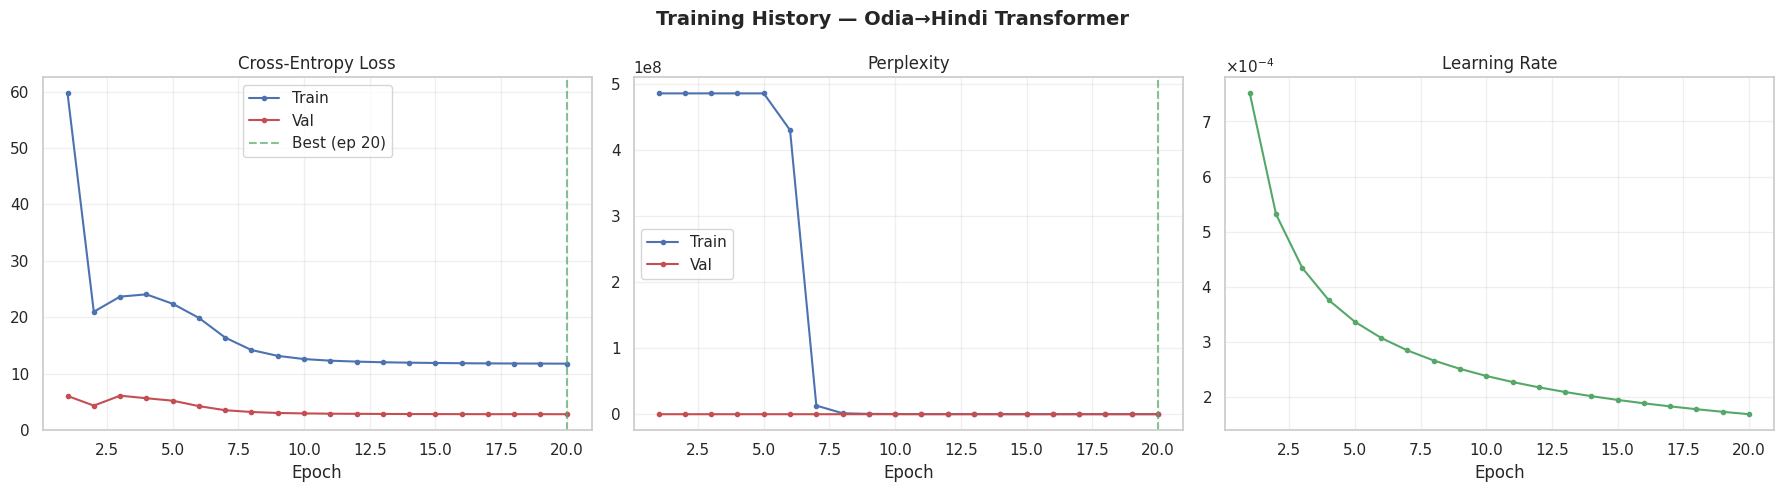

   Saved → /kaggle/working/outputs/training_curves.png


In [ ]:
def plot_training_history(history, save_dir):
    epochs  = list(range(1, len(history['train_loss']) + 1))
    best_ep = int(np.argmin(history['val_loss'])) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training History — Odia→Hindi Transformer', fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    ax.plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
    ax.axvline(best_ep, color='g', linestyle='--', alpha=0.7, label=f'Best (ep {best_ep})')
    ax.set_title('Cross-Entropy Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs, history['train_ppl'], 'b-o', ms=3, label='Train')
    ax.plot(epochs, history['val_ppl'],   'r-o', ms=3, label='Val')
    ax.axvline(best_ep, color='g', linestyle='--', alpha=0.7)
    ax.set_title('Perplexity'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[2]
    ax.plot(epochs, history['lr'], 'g-o', ms=3)
    ax.set_title('Learning Rate'); ax.set_xlabel('Epoch')
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.grid(alpha=0.3)

    plt.tight_layout()
    path = f'{save_dir}/training_curves.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'   Saved → {path}')

plot_training_history(history, Config.OUTPUT_DIR)


## Cell 15 — Beam Search Decoder

In [ ]:
class BeamSearchDecoder:

    def __init__(
        self,
        model:          nn.Module,
        src_vocab:      Vocabulary,
        tgt_vocab:      Vocabulary,
        device:         torch.device,
        beam_size:      int   = Config.BEAM_SIZE,
        temperature:    float = Config.TEMPERATURE,
        length_penalty: float = Config.LENGTH_PENALTY,
        max_len:        int   = Config.MAX_DECODE_LEN,
    ):
        self.model          = model
        self.src_vocab      = src_vocab
        self.tgt_vocab      = tgt_vocab
        self.device         = device
        self.beam_size      = beam_size
        self.temperature    = temperature
        self.length_penalty = length_penalty
        self.max_len        = max_len

        self.pad_idx = Vocabulary.PAD_IDX
        self.sos_idx = Vocabulary.SOS_IDX
        self.eos_idx = Vocabulary.EOS_IDX

    @torch.no_grad()
    def decode(self, src: torch.Tensor) -> List[int]:
        self.model.eval()
        src = src.to(self.device)

        memory, src_pad_mask = self.model.encode(src)  # (1, S, d)

        B = self.beam_size
        memory       = memory.expand(B, -1, -1)
        src_pad_mask = src_pad_mask.expand(B, -1)

        beams     = [([self.sos_idx], 0.0)]
        completed = []

        for _ in range(self.max_len):
            if not beams:
                break

            seqs    = [b[0] for b in beams]
            lengths = [len(s) for s in seqs]
            max_l   = max(lengths)
            tgt_batch = torch.tensor(
                [s + [self.pad_idx] * (max_l - len(s)) for s in seqs],
                dtype=torch.long, device=self.device
            )

            _mem   = memory[:len(beams)]
            _smask = src_pad_mask[:len(beams)]
            with torch.amp.autocast('cuda', enabled=Config.USE_AMP):
                out = self.model.decode(tgt_batch, _mem, _smask)  # (n_beams, T, V)

            candidates = []
            for i, (tok_ids, beam_score) in enumerate(beams):
                last_pos  = lengths[i] - 1
                logits_i  = out[i, last_pos, :] / self.temperature
                log_probs = F.log_softmax(logits_i, dim=-1)
                top_log_probs, top_idxs = log_probs.topk(B)

                for log_p, idx in zip(top_log_probs.tolist(), top_idxs.tolist()):
                    new_score = beam_score + log_p
                    new_ids   = tok_ids + [idx]
                    if idx == self.eos_idx:

                        length_pen  = ((5 + len(new_ids)) / 6) ** self.length_penalty
                        final_score = new_score / length_pen
                        completed.append((new_ids, final_score))
                    else:
                        candidates.append((new_ids, new_score))

            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:B]

            if len(completed) >= B:
                break

        if not completed:
            for tok_ids, score in beams:
                length_pen = ((5 + len(tok_ids)) / 6) ** self.length_penalty
                completed.append((tok_ids + [self.eos_idx], score / length_pen))

        completed.sort(key=lambda x: x[1], reverse=True)
        best_ids = completed[0][0]

        return [t for t in best_ids if t not in (self.sos_idx, self.eos_idx, self.pad_idx)]

    def translate(self, odia_text: str) -> str:
        """
        Full pipeline: raw Odia text → cleaned → BPE segmented → beam decoded → Hindi.
        """
        cleaner   = TextCleaner(lang='or')
        cleaned   = cleaner.clean(odia_text)
        if not cleaned.strip():
            return ''

        segmented = odia_morph.segment_sentence(cleaned)

        src_ids    = self.src_vocab.encode(segmented, add_special=True)[:Config.MAX_LEN + 2]
        src_tensor = torch.tensor([src_ids], dtype=torch.long)

        tgt_ids = self.decode(src_tensor)

        raw = self.tgt_vocab.decode(tgt_ids, skip_special=True)
        return ' '.join(t for t in raw.split() if t != '<unk>')


print('📦 Loading best model weights...')
model.load_state_dict(torch.load(f'{Config.MODEL_DIR}/best_model.pt', map_location=DEVICE))
model.eval()

decoder = BeamSearchDecoder(
    model=model,
    src_vocab=src_vocab,
    tgt_vocab=tgt_vocab,
    device=DEVICE,
    beam_size=Config.BEAM_SIZE,
    temperature=Config.TEMPERATURE,
    length_penalty=Config.LENGTH_PENALTY,
    max_len=Config.MAX_DECODE_LEN,
)
print('✅ BeamSearchDecoder ready with best model weights.')

📦 Loading best model weights...
✅ BeamSearchDecoder ready with best model weights.


## Cell 16 — Evaluation & Metrics (BLEU, ChrF, TER)

In [ ]:
class Evaluator:
    def __init__(
        self,
        model:       nn.Module,
        decoder:     BeamSearchDecoder,
        tgt_vocab:   Vocabulary,
        device:      torch.device,
    ):
        self.model     = model
        self.decoder   = decoder
        self.tgt_vocab = tgt_vocab
        self.device    = device

    def generate_translations(self, df_subset: pd.DataFrame, n_samples: int = 2000) -> Tuple[List[str], List[str]]:
        sample     = df_subset.sample(min(n_samples, len(df_subset)), random_state=SEED)
        hypotheses = []
        references = []

        print(f'🔍 Generating {len(sample)} translations...')
        for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Translating'):
            try:
                pred_str = self.decoder.translate(row['odia'])
            except Exception:
                pred_str = ''

            def _clean_out(t):
                return (t.replace(' .', '.').replace(' ,', ',')
                         .replace(' ?', '?').replace(' !', '!')
                         .replace(' )', ')').replace('( ', '(')
                         .strip())

            hypotheses.append(_clean_out(pred_str))
            references.append(_clean_out(row['hindi']))

        return hypotheses, references, sample

    def compute_all_metrics(self, hypotheses: List[str], references: List[str]) -> dict:
        refs_wrapped = [references]
        results      = {}

        for n in [1, 2, 3, 4]:
            results[f'BLEU-{n}'] = round(
                BLEU(max_ngram_order=n).corpus_score(hypotheses, refs_wrapped).score, 2
            )

        results['ChrF'] = round(
            CHRF().corpus_score(hypotheses, refs_wrapped).score, 2
        )

        try:
            results['TER'] = round(
                TER().corpus_score(hypotheses, refs_wrapped).score, 2
            )
        except Exception:
            results['TER'] = float('nan')

        bleu_sent  = BLEU(effective_order=True)
        sent_bleus = [
            bleu_sent.sentence_score(h, [r]).score
            for h, r in zip(hypotheses, references)
            if h.strip()
        ]
        results['Avg_SentBLEU'] = round(float(np.mean(sent_bleus)) if sent_bleus else 0.0, 2)

        results['Empty_Rate_%'] = round(
            sum(1 for h in hypotheses if not h.strip()) / len(hypotheses) * 100, 1
        )

        return results

    def evaluate_test_set(self, df_test: pd.DataFrame, n_samples: int = 2000) -> Tuple[dict, List, List]:
        hypotheses, references, sample = self.generate_translations(df_test, n_samples)
        metrics = self.compute_all_metrics(hypotheses, references)

        print('\n' + '='*55)
        print('  EVALUATION RESULTS (Test Set)')
        print('='*55)
        for metric, score in metrics.items():
            if isinstance(score, float) and not np.isnan(score):
                bar = '█' * int(min(score, 100) / 2)
            else:
                bar = ''
            print(f'  {metric:<18}: {score:>7}  {bar}')
        print('='*55)

        print('\n📝 Translation examples:')
        for i in range(min(5, len(sample))):
            row = sample.iloc[i]
            print(f'  OR  : {row["odia"][:120]}')
            print(f'  REF : {row["hindi"][:120]}')
            print(f'  PRED: {hypotheses[i][:120]}')
            print()

        bleu4 = metrics.get('BLEU-4', 0)
        print('📋 BLEU-4 Interpretation:')
        if   bleu4 >= 40: print('  ✅ Excellent — near human quality')
        elif bleu4 >= 30: print('  ✅ Good — understandable translation')
        elif bleu4 >= 20: print('  ⚠️  Fair — gist is clear')
        elif bleu4 >= 10: print('  ⚠️  Poor — some correct phrases')
        else:             print('  ❌ Very poor — barely usable')

        with open(f'{Config.OUTPUT_DIR}/test_metrics.json', 'w') as f:
            json.dump(metrics, f, indent=2)
        print('\n✅ Metrics saved!')

        return metrics, hypotheses, references

evaluator    = Evaluator(model, decoder, tgt_vocab, DEVICE)
print('📊 Evaluating on test set...')
test_metrics, hyps, refs = evaluator.evaluate_test_set(df_test, n_samples=2000)

📊 Evaluating on test set...
🔍 Generating 2000 translations...


Translating:   0%|          | 0/2000 [00:00<?, ?it/s]


  EVALUATION RESULTS (Test Set)
  BLEU-1            :   64.18  ████████████████████████████████
  BLEU-2            :   56.82  ████████████████████████████
  BLEU-3            :   51.01  █████████████████████████
  BLEU-4            :   46.12  ███████████████████████
  ChrF              :   59.98  █████████████████████████████
  TER               :   37.14  ██████████████████
  Avg_SentBLEU      :   49.68  ████████████████████████
  Empty_Rate_%      :     0.4  

📝 Translation examples:
  OR  : ଅଭିନଯ଼ ବ୍ଯ଼ତୀତ ଅନ୍ଯ଼ କୌଣସି କ୍ଷେତ୍ରରେ ସକ୍ରିଯ଼ ଥିବା ବିଷଯ଼ରେ କୌଣସି ସୂଚନା ପ୍ରଦାନ କରାଯାଇନାହିଁ
  REF : तन्वी ठक्कर के अभिनय के अलावा किसी अन्य क्षेत्र में सक्रिय होने की जानकारी नहीं दी गई है
  PRED: अभिनय के अलावा किसी अन्य क्षेत्र में सक्रिय रूप से किसी भी जानकारी प्रदान नहीं की गई है

  OR  : ପରେ ଜେରୀ ଡି ସିଲଭା ପାକିସ୍ତାନରେ ଶ୍ରୀଲଙ୍କାର ହାଇ କମିଶନର ଭାବେ କାର୍ଯ୍ଯ଼ କରିଥିଲେ
  REF : जेरी डी सिल्वा ने बाद में पाकिस्तान में श्रीलंका के उच्चायुक्त के रूप में कार्य किया
  PRED: जेरी डी सिल्वा ने पाकिस्तान में श

## Cell 17 — Evaluation Visualization

/tmp/ipykernel_55/1615796494.py:67: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_55/1615796494.py:67: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_55/1615796494.py:67: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_55/1615796494.py:67: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_55/1615796494.py:67: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inches='tight', dpi=150)
/tmp/ipykernel_55/1615796494.py:67: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, bbox_inche

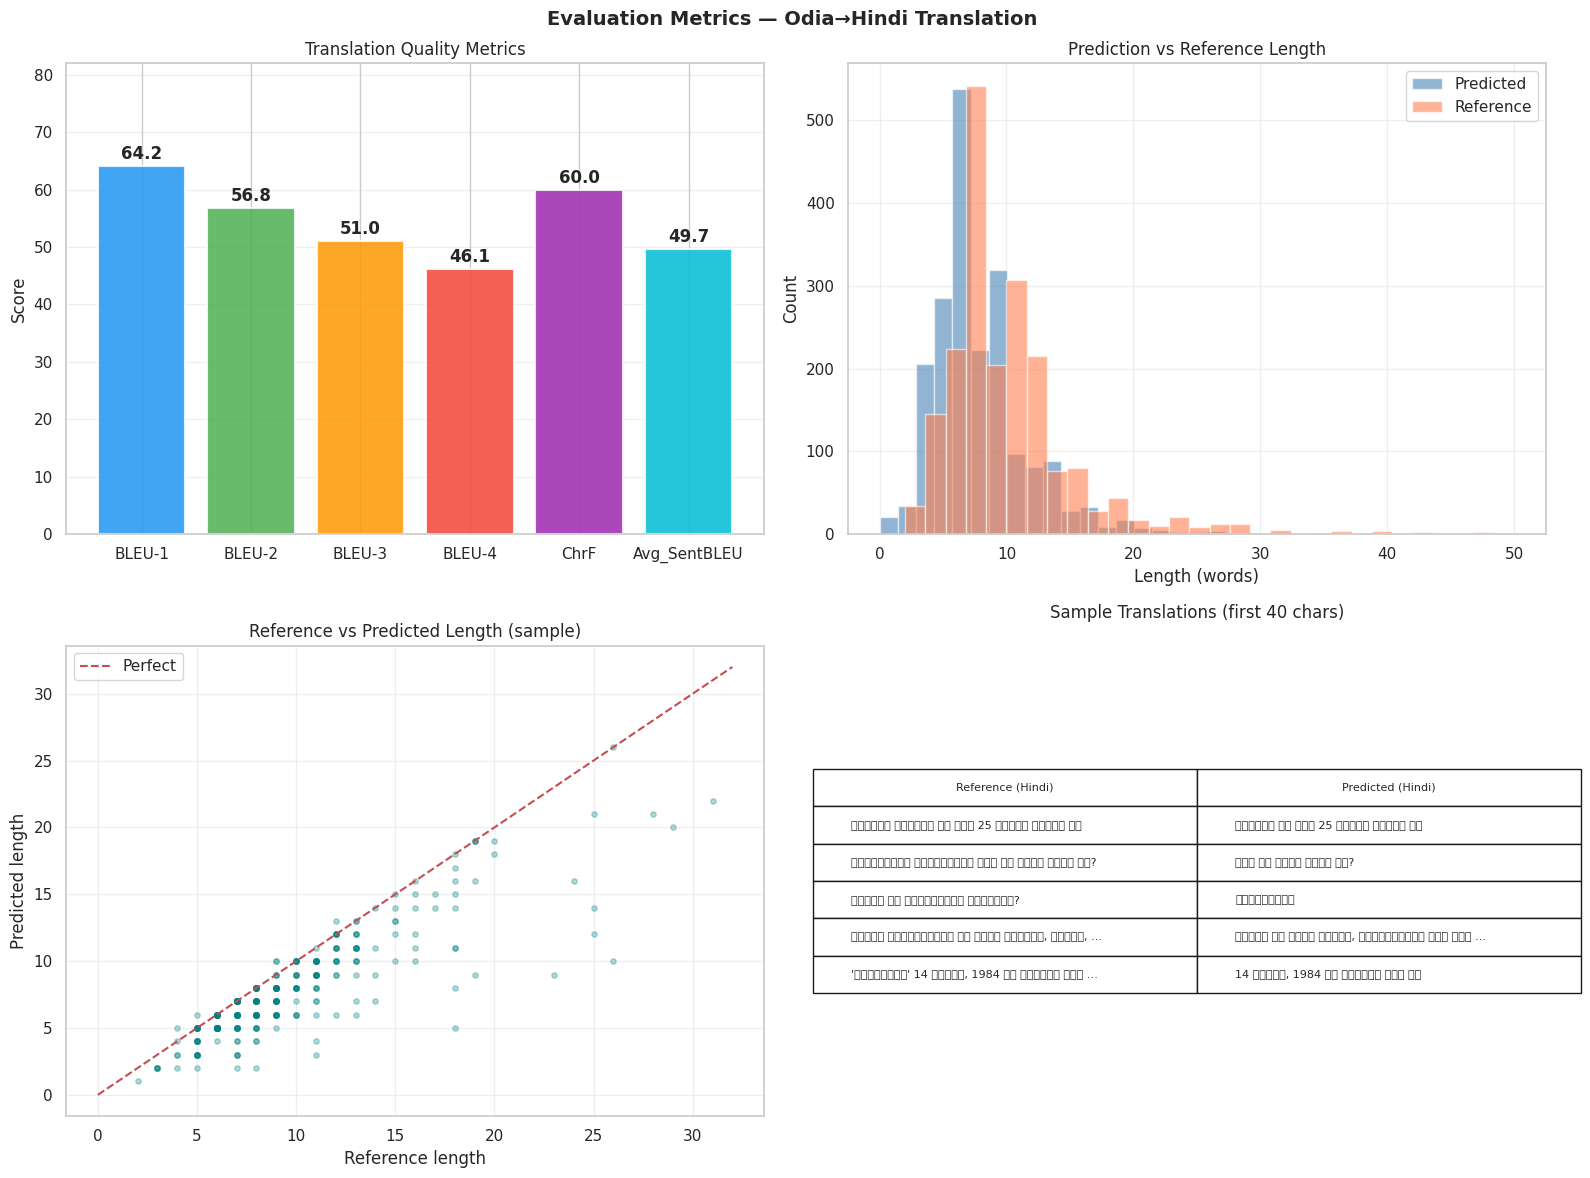

✅ Saved evaluation plots → /kaggle/working/outputs/evaluation_plots.png


In [ ]:
def plot_evaluation(test_metrics: dict, hyps: List[str], refs: List[str], save_dir: str):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Evaluation Metrics — Odia→Hindi Translation', fontsize=14, fontweight='bold')

    # 1. Metric Bar Chart 
    ax = axes[0, 0]
    metric_keys   = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'ChrF', 'Avg_SentBLEU']
    metric_values = [test_metrics.get(k, 0) for k in metric_keys]
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#00BCD4']
    bars = ax.bar(metric_keys, metric_values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, metric_values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
    ax.set_title('Translation Quality Metrics')
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(metric_values) * 1.2 + 5)
    ax.grid(axis='y', alpha=0.3)

    # 2. Hypothesis length distribution
    ax = axes[0, 1]
    hyp_lens = [len(h.split()) for h in hyps]
    ref_lens = [len(r.split()) for r in refs]
    ax.hist(hyp_lens, bins=30, alpha=0.6, color='steelblue', label='Predicted')
    ax.hist(ref_lens, bins=30, alpha=0.6, color='coral',     label='Reference')
    ax.set_title('Prediction vs Reference Length')
    ax.set_xlabel('Length (words)')
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(alpha=0.3)

    # 3. Length ratio scatter
    ax = axes[1, 0]
    ax.scatter(ref_lens[:300], hyp_lens[:300], alpha=0.3, s=15, color='teal')
    max_len = max(max(ref_lens[:300]), max(hyp_lens[:300])) + 1
    ax.plot([0, max_len], [0, max_len], 'r--', linewidth=1.5, label='Perfect')
    ax.set_title('Reference vs Predicted Length (sample)')
    ax.set_xlabel('Reference length')
    ax.set_ylabel('Predicted length')
    ax.legend()
    ax.grid(alpha=0.3)

    # 4. Sample translations table
    ax = axes[1, 1]
    ax.axis('off')
    sample_idx = random.sample(range(len(hyps)), min(5, len(hyps)))
    table_data = []
    for i in sample_idx:
        ref_cell = refs[i][:40] + '…' if len(refs[i]) > 40 else refs[i]
        hyp_cell = hyps[i][:40] + '…' if len(hyps[i]) > 40 else hyps[i]
        table_data.append([ref_cell, hyp_cell])
    tbl = ax.table(
        cellText=table_data,
        colLabels=['Reference (Hindi)', 'Predicted (Hindi)'],
        loc='center', cellLoc='left'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.1, 2.0)
    ax.set_title('Sample Translations (first 40 chars)', pad=20)

    plt.tight_layout()
    path = f'{save_dir}/evaluation_plots.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Saved evaluation plots → {path}')


plot_evaluation(test_metrics, hyps, refs, Config.OUTPUT_DIR)

## Cell 18 — Interactive Translation

In [ ]:
def _detokenize_morph(text: str) -> str:
    tokens = [t for t in text.split() if t not in ('<unk>', '▁')]
    return ' '.join(tokens)


def translate_odia_to_hindi(odia_text: str, verbose: bool = True) -> str:
    model.eval()

    odia_cleaner = TextCleaner(lang='or')
    cleaned      = odia_cleaner.clean(odia_text)
    if not cleaned.strip():
        if verbose:
            print(f'  Input (Odia)    : {odia_text}')
            print(f'  Cleaned         : [empty after cleaning]')
            print(f'  Output (Hindi)  : [no output]')
        return ''

    segmented = odia_morph.segment_sentence(cleaned)

    src_ids = self.src_vocab.encode(segmented, add_special=True)[:Config.MAX_LEN + 1] + [self.src_vocab.EOS_IDX]
    src_t   = torch.tensor([src_ids], dtype=torch.long)

    tgt_ids = decoder.decode(src_t)

    raw_hindi = tgt_vocab.decode(tgt_ids, skip_special=True)
    hindi     = _detokenize_morph(raw_hindi)

    if verbose:
        seg_display = (segmented[:80] + '...') if len(segmented) > 80 else segmented
        print(f'  Input (Odia)    : {odia_text}')
        print(f'  Cleaned         : {cleaned}')
        print(f'  Segmented (Morph): {seg_display}')
        print(f'  Output (Hindi)  : {hindi}')
    return hindi


test_odia_sentences = [
    'ନମସ୍କାର',
    'ଆଜି ସକାଳୁ ପାଗ ବହୁତ ଖରାପ ଥିବାରୁ ମୁଁ ଅଫିସ୍ ନଯାଇ ଘରେ ରହି ଇଣ୍ଟରନେଟ୍‌ରେ କିଛି ଜରୁରୀ କାମ ଶେଷ କଲି।',
    'ଆମ ଗାଁ ପାଖରେ ଥିବା ବଡ଼ ନଦୀଟି ବର୍ଷା ଦିନେ ପୂର୍ଣ୍ଣ ରୂପ ଧାରଣ କରି ଚାଷ ଜମିଗୁଡ଼ିକୁ ପାଣିରେ ବୁଡ଼ାଇ ଦିଏ।',
    'ସମୟର ସଦୁପଯୋଗ କଲେ ମଣିଷ ଜୀବନରେ ବହୁତ ଉନ୍ନତି କରିପାରିବ ଏବଂ ନିଜର ସମସ୍ତ ଲକ୍ଷ୍ୟ ହାସଲ କରିପାରିବ।',
    'ଆସନ୍ତା କାଲି ସ୍କୁଲର ବାର୍ଷିକୋତ୍ସବ ଥିବାରୁ ସମସ୍ତ ଛାତ୍ରଛାତ୍ରୀ ମାନେ ବହୁତ ଉତ୍ସାହର ସହ ପ୍ରସ୍ତୁତି ଚଳାଇଛନ୍ତି।',
    'ସ୍ୱାସ୍ଥ୍ୟ ହିଁ ସମ୍ପଦ, ତେଣୁ ଆମକୁ ସବୁବେଳେ ପୌଷ୍ଟିକ ଖାଦ୍ୟ ଖାଇବା ସହିତ ନିୟମିତ ବ୍ୟାୟାମ କରିବା ଆବଶ୍ୟକ।',
    'କଳିଙ୍ଗ ଷ୍ଟାଡିୟମ୍‌ରେ ଚାଲିଥିବା ଫୁଟବଲ୍ ମ୍ୟାଚ୍‌ ଦେଖିବାକୁ ହଜାର ହଜାର ଦର୍ଶକଙ୍କ ଭିଡ଼ ଜମିଥିଲା ଏବଂ ପରିବେଶ ବହୁତ ରୋମାଞ୍ଚକର ଥିଲା।',
    'କେନ୍ଦ୍ର ସରକାର ଗ୍ରାମାଞ୍ଚଳର ବିକାଶ ପାଇଁ ନୂଆ ନୂଆ ଯୋଜନା ପ୍ରଣୟନ କରିବା ଦ୍ୱାରା ଗରିବ ଲୋକମାନେ ଉପକୃତ ହେଉଛନ୍ତି।',
]

print('\n' + '='*70)
print('  ODIA → HINDI TRANSLATION RESULTS')
print('='*70)
for i, sent in enumerate(test_odia_sentences, 1):
    print(f'\n[{i}]')
    translate_odia_to_hindi(sent, verbose=True)
    print()
print('='*70)


  ODIA → HINDI TRANSLATION RESULTS

[1]
  Input (Odia)    : ନମସ୍କାର
  Cleaned         : ନମସ୍କାର
  Segmented (Morph): ନମସ୍କାର
  Output (Hindi)  : हैलो


[2]
  Input (Odia)    : ମୁଁ ଠିକ ଅଛି
  Cleaned         : ମୁଁ ଠିକ ଅଛି
  Segmented (Morph): ମୁଁ ଠିକ ଅଛି
  Output (Hindi)  : मैं ठीक है


[3]
  Input (Odia)    : ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ
  Cleaned         : ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ
  Segmented (Morph): ଭୁବନେଶ୍ୱର ଓଡ଼ିଶାର ରାଜଧାନୀ
  Output (Hindi)  : भुवनेश्वर की राजधानी ओडिशा में


[4]
  Input (Odia)    : ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି
  Cleaned         : ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି
  Segmented (Morph): ଆଜି ପାଣିପାଗ ବହୁତ ଭଲ ଅଛି
  Output (Hindi)  : आज मौसम बहुत अच्छा है


[5]
  Input (Odia)    : ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା
  Cleaned         : ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା
  Segmented (Morph): ସ୍କୁଲ ଖୋଲା ହୋଇଗଲା
  Output (Hindi)  : स्कूल खुला है


[6]
  Input (Odia)    : ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ
  Cleaned         : ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ
  Segmented (Morph): ରୋଟି ଓ ଡ଼ାଲ ବହୁତ ସୁଆଦ
  Output (Hindi)  : रोटी ओ बहुत


[7]
  Input (Odi

## Cell 19 — Model Summary & Save Final Model

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19: MODEL SUMMARY & SAVE
# ─────────────────────────────────────────────────────────────────────────────
def model_summary(model: nn.Module):
    """Print a detailed parameter summary."""
    print('\n' + '='*65)
    print('  MODEL PARAMETER SUMMARY')
    print('='*65)
    total  = 0
    groups = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        top = name.split('.')[0]
        n   = param.numel()
        groups[top] = groups.get(top, 0) + n
        total += n
    print(f'  {"Component":<30} {"Parameters":>12}')
    print('  ' + '-'*45)
    for comp, n in sorted(groups.items(), key=lambda x: -x[1]):
        print(f'  {comp:<30} {n:>12,}  ({n/total*100:.1f}%)')
    print('  ' + '='*45)
    print(f'  {"TOTAL":<30} {total:>12,}')
    print(f'  {"TOTAL (M)":<30} {total/1e6:>11.2f}M')
    print('='*65)
    print(f'\n  Architecture:')
    print(f'    d_model         = {Config.D_MODEL}')
    print(f'    n_heads         = {Config.N_HEADS}')
    print(f'    enc_layers      = {Config.N_ENC_LAYERS}')
    print(f'    dec_layers      = {Config.N_DEC_LAYERS}')
    print(f'    d_ff            = {Config.D_FF}')
    print(f'    dropout         = {Config.DROPOUT}')
    print(f'    src_vocab       = {src_vocab.size:,}')
    print(f'    tgt_vocab       = {tgt_vocab.size:,}')
    print(f'    max_pos_enc     = {Config.MAX_POS_ENC}')
    print('='*65)

model_summary(model)

# ── Save final model bundle ───────────────────────────────────────────────────
final_bundle = {
    # Model weights (best)
    'model_state_dict': model.state_dict(),
    # Architecture config (needed to reconstruct the model)
    'model_config': {
        'src_vocab_size':  src_vocab.size,
        'tgt_vocab_size':  tgt_vocab.size,
        'd_model':         Config.D_MODEL,
        'nhead':           Config.N_HEADS,
        'num_enc_layers':  Config.N_ENC_LAYERS,
        'num_dec_layers':  Config.N_DEC_LAYERS,
        'dim_feedforward': Config.D_FF,
        'dropout':         Config.DROPOUT,
        'max_pos_enc':     Config.MAX_POS_ENC,
    },
    # ✅ FIXED: Morfessor model paths (not BPE)
    'morph_model_paths': {
        'odia':  odia_morph.model_path,
        'hindi': hindi_morph.model_path,
    },
    # Evaluation results
    'test_metrics': test_metrics,
    # Training history
    'training_history': history,
    # Best val loss achieved
    'best_val_loss': early_stopper.best_loss,
}

final_path = f'{Config.MODEL_DIR}/odia_hindi_translator_final.pt'
torch.save(final_bundle, final_path)

# Save vocabularies
src_vocab.save(f'{Config.MODEL_DIR}/vocab_odia.pkl')
tgt_vocab.save(f'{Config.MODEL_DIR}/vocab_hindi.pkl')

print(f'\n✅ Final model saved:')
print(f'   {final_path}')
print(f'   {Config.MODEL_DIR}/vocab_odia.pkl')
print(f'   {Config.MODEL_DIR}/vocab_hindi.pkl')
print(f'   {odia_morph.model_path}  (Morfessor — Odia)')
print(f'   {hindi_morph.model_path}  (Morfessor — Hindi)')

# ── File sizes ────────────────────────────────────────────────────────────────
files_to_check = [
    final_path,
    f'{Config.MODEL_DIR}/vocab_odia.pkl',
    f'{Config.MODEL_DIR}/vocab_hindi.pkl',
    odia_morph.model_path,
    hindi_morph.model_path,
]
print()
for f in files_to_check:
    if os.path.exists(f):
        sz = os.path.getsize(f) / 1e6
        print(f'   {os.path.basename(f)}: {sz:.1f} MB')
    else:
        print(f'   {os.path.basename(f)}: NOT FOUND')


  MODEL PARAMETER SUMMARY
  Component                        Parameters
  ---------------------------------------------
  fc_out                           10,280,000  (29.6%)
  src_embed                        10,240,000  (29.5%)
  tgt_embed                        10,240,000  (29.5%)
  transformer                       3,954,688  (11.4%)
  TOTAL                            34,714,688
  TOTAL (M)                            34.71M

  Architecture:
    d_model         = 256
    n_heads         = 8
    enc_layers      = 3
    dec_layers      = 3
    d_ff            = 512
    dropout         = 0.1
    src_vocab       = 40,000
    tgt_vocab       = 40,000
    max_pos_enc     = 128
  [Odia] Saved → /kaggle/working/models/vocab_odia.pkl
  [Hindi] Saved → /kaggle/working/models/vocab_hindi.pkl

✅ Final model saved:
   /kaggle/working/models/odia_hindi_translator_final.pt
   /kaggle/working/models/vocab_odia.pkl
   /kaggle/working/models/vocab_hindi.pkl
   /kaggle/working/morph_models/morfessor_

## Cell 20 — Load & Inference (Standalone — use after downloading model)

In [ ]:


class OdiaHindiTranslatorInference:
    

    def __init__(self, model_path, odia_vocab_path, hindi_vocab_path,
                 odia_morph_path, hindi_morph_path, device=DEVICE):
        self.device = device

        # Load vocabularies
        self.src_vocab = Vocabulary.load(odia_vocab_path)
        self.tgt_vocab = Vocabulary.load(hindi_vocab_path)
        print(f'  Odia vocab  : {self.src_vocab.size:,} tokens')
        print(f'  Hindi vocab : {self.tgt_vocab.size:,} tokens')

        # Load model
        bundle = torch.load(model_path, map_location=device)
        cfg    = bundle['model_config']
        self.model = TranslatorTransformer(
            src_vocab_size = cfg['src_vocab_size'],
            tgt_vocab_size = cfg['tgt_vocab_size'],
            d_model        = cfg['d_model'],
            nhead          = cfg['nhead'],
            num_enc_layers = cfg['num_enc_layers'],
            num_dec_layers = cfg['num_dec_layers'],
            dim_feedforward= cfg['dim_feedforward'],
            dropout        = cfg['dropout'],
            max_pos_enc    = cfg['max_pos_enc'],
        ).to(device)
        self.model.load_state_dict(bundle['model_state_dict'])
        self.model.eval()
        print(f'  Model params: {self.model.count_parameters():,}')

        # ✅ Load Morfessor segmenter for Odia
        self.odia_morph = MorphSegmenter(
            lang='or', morph_dir=os.path.dirname(odia_morph_path)
        )
        self.odia_morph.load()
        print(f'  Odia Morfessor: {odia_morph_path}')

        # Decoder
        self.decoder = BeamSearchDecoder(
            model=self.model, src_vocab=self.src_vocab,
            tgt_vocab=self.tgt_vocab, device=device,
        )
        print('  ✅ Ready!')

    def _segment(self, text: str) -> str:
        """Morfessor segment a cleaned Odia sentence."""
        return self.odia_morph.segment_sentence(text)

    def translate(self, odia_text: str) -> str:
        cleaner   = TextCleaner(lang='or')
        cleaned   = cleaner.clean(odia_text)
        if not cleaned.strip():
            return ''
        segmented = self._segment(cleaned)
        src_ids   = self.src_vocab.encode(segmented, add_special=True)[:Config.MAX_LEN + 2]
        src_t     = torch.tensor([src_ids], dtype=torch.long)
        tgt_ids   = self.decoder.decode(src_t)
        raw       = self.tgt_vocab.decode(tgt_ids, skip_special=True)
        return ' '.join(t for t in raw.split() if t != '<unk>')

    def translate_batch(self, odia_texts: List[str]) -> List[str]:
        return [self.translate(t) for t in odia_texts]


# ── Demo (uses current session's objects) ─────────────────────────────────────
print('📱 Quick inference demo:')
demo_sentences = [
    'ଆଜିକାଲିର ସମୟରେ ଇଣ୍ଟରନେଟ୍ ବିନା ଜୀବନ ଯାପନ କରିବା ପ୍ରାୟ ଅସମ୍ଭବ ହୋଇପଡ଼ିଛି',
    'ଓଡ଼ିଶା ଏକ ସୁନ୍ଦର ରାଜ୍ୟ',
    'ଆମ ରାଜ୍ୟ ଓଡ଼ିଶାର କଳା, ସଂସ୍କୃତି ଏବଂ ପରମ୍ପରା ସାରା ବିଶ୍ୱରେ ଖୁବ୍ ପ୍ରସିଦ୍ଧ',
    'ସେ କହିଲେ ଯେ ଯଦି ଆଜି ବର୍ଷା ହୁଏ, ତେବେ ଆମେ ବାହାରକୁ ବୁଲିବାକୁ ଯାଇପାରିବା ନାହିଁ',
    'ଆମେ ପିଲାଦିନେ ଯେଉଁ ଗାଁରେ ରହୁଥିଲୁ, ସେଠାକାର ପରିବେଶ ବହୁତ ଶାନ୍ତ ଏବଂ ସୁନ୍ଦର ଥିଲା',
    'ମୁଁ ଗତକାଲି ବଜାରକୁ ଯାଇଥିଲି କିନ୍ତୁ ସେଠାରେ ବହୁତ ଭିଡ଼ ଥିବାରୁ ମୁଁ କିଛି କିଣି ପାରିଲି ନାହିଁ',
    'ବିଜ୍ଞାନ ଏବଂ ପ୍ରଯୁକ୍ତିବିଦ୍ୟାର ବିକାଶ ଯୋଗୁଁ ଆଜି ମଣିଷର ଜୀବନଶୈଳୀ ପୂର୍ବ ଅପେକ୍ଷା ବହୁତ ସହଜ ଏବଂ ଆରାମଦାୟକ ହୋଇପାରିଛି।',
    'ଆମକୁ ପରିବେଶକୁ ସୁସ୍ଥ ରଖିବା ପାଇଁ ଅଧିକରୁ ଅଧିକ ଗଛ ଲଗାଇବା ସହିତ ପ୍ଲାଷ୍ଟିକ ବ୍ୟବହାର ବନ୍ଦ କରିବାକୁ ପଡ଼ିବ।'
]

print('\n{:<50} → {}'.format('Odia Input', 'Hindi Output'))
print('-'*80)
for sent in demo_sentences:
    translation = translate_odia_to_hindi(sent, verbose=False)
    print(f'{sent[:50]:<50} → {translation}')

print('\n--- To use after downloading model files ---')
print('translator = OdiaHindiTranslatorInference(')
print('    model_path       = "/kaggle/working/models/odia_hindi_translator_final.pt",')
print('    odia_vocab_path  = "/kaggle/working/models/vocab_odia.pkl",')
print('    hindi_vocab_path = "/kaggle/working/models/vocab_hindi.pkl",')
print('    odia_morph_path  = "/kaggle/working/morph_models/morfessor_or.bin",')
print('    hindi_morph_path = "/kaggle/working/morph_models/morfessor_hi.bin",')
print(')')
print('print(translator.translate("ନମସ୍କାର"))')

📱 Quick inference demo:

Odia Input                                         → Hindi Output
--------------------------------------------------------------------------------
ଆଜିକାଲିର ସମୟରେ ଇଣ୍ଟରନେଟ୍ ବିନା ଜୀବନ ଯାପନ କରିବା ପ୍ରା → इंटरनेट पर जीवन के बिना को
ଓଡ଼ିଶା ଏକ ସୁନ୍ଦର ରାଜ୍ୟ                             → ओडिशा एक सुंदर
ଆମ ରାଜ୍ୟ ଓଡ଼ିଶାର କଳା, ସଂସ୍କୃତି ଏବଂ ପରମ୍ପରା ସାରା ବି → हमारे ओडिशा कला, संस्कृति और परंपराओं दुनिया भर में प्रसिद्ध हैं
ସେ କହିଲେ ଯେ ଯଦି ଆଜି ବର୍ଷା ହୁଏ, ତେବେ ଆମେ ବାହାରକୁ ବୁ → वह है कि आज बारिश में वर्षा होती है, तो हम बाहर हो सकते हैं
ଆମେ ପିଲାଦିନେ ଯେଉଁ ଗାଁରେ ରହୁଥିଲୁ, ସେଠାକାର ପରିବେଶ ବହ → हम जो उस समय पर्यावरण बहुत शांत और शांत थे
ମୁଁ ଗତକାଲି ବଜାରକୁ ଯାଇଥିଲି କିନ୍ତୁ ସେଠାରେ ବହୁତ ଭିଡ଼  → मुझे यकीन नहीं है, लेकिन वहाँ बहुत बहुत ही है, लेकिन मैं कुछ नहीं हूँ

--- To use after downloading model files ---
translator = OdiaHindiTranslatorInference(
    model_path       = "/kaggle/working/models/odia_hindi_translator_final.pt",
    odia_vocab_path  = "/kaggle/working/models/vocab_odia.pkl

## Cell 21 — Final Summary Dashboard

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21: FINAL SUMMARY DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
def print_final_summary(
    df:           pd.DataFrame,
    model:        nn.Module,
    history:      dict,
    test_metrics: dict,
    src_vocab:    Vocabulary,
    tgt_vocab:    Vocabulary,
):
    border = '═' * 65
    print(f'\n{border}')
    print(f'  ODIA → HINDI TRANSFORMER — FINAL SUMMARY')
    print(border)

    print(f'\n  📊 DATASET')
    print(f'    Total pairs          : {len(df):,}')
    print(f'    Train / Val / Test   : ~{len(df_train):,} / {len(df_val):,} / {len(df_test):,}')
    print(f'    Odia avg length      : {df["odia_len"].mean():.1f} words')
    print(f'    Hindi avg length     : {df["hindi_len"].mean():.1f} words')

    print(f'\n  🔡 VOCABULARY')
    print(f'    Odia vocab size      : {src_vocab.size:,}  (Morfessor)')
    print(f'    Hindi vocab size     : {tgt_vocab.size:,}  (Morfessor)')

    print(f'\n  🏗️  MODEL')
    print(f'    Parameters           : {model.count_parameters()/1e6:.1f}M')
    print(f'    Architecture         : Transformer (Pre-LayerNorm)')
    print(f'    Encoder layers       : {Config.N_ENC_LAYERS}')
    print(f'    Decoder layers       : {Config.N_DEC_LAYERS}')
    print(f'    d_model              : {Config.D_MODEL}')
    print(f'    Attention heads      : {Config.N_HEADS}')
    print(f'    FFN dim              : {Config.D_FF}')

    print(f'\n  🎯 TRAINING')
    n_ep = len(history["train_loss"])
    print(f'    Epochs trained       : {n_ep}')
    print(f'    Best val loss        : {early_stopper.best_loss:.4f}')
    print(f'    Final train PPL      : {history["train_ppl"][-1]:.1f}')
    print(f'    Final val   PPL      : {history["val_ppl"][-1]:.1f}')

    print(f'\n  📈 EVALUATION (Test, 2000 samples)')
    for k, v in test_metrics.items():
        print(f'    {k:<22}: {v}')

    print(f'\n  💾 SAVED FILES')
    print(f'    {Config.MODEL_DIR}/odia_hindi_translator_final.pt')
    print(f'    {Config.MODEL_DIR}/vocab_odia.pkl')
    print(f'    {Config.MODEL_DIR}/vocab_hindi.pkl')
    print(f'    {Config.MORPH_DIR}/morfessor_or.bin   (Morfessor — Odia)')
    print(f'    {Config.MORPH_DIR}/morfessor_hi.bin   (Morfessor — Hindi)')
    print(f'    {Config.OUTPUT_DIR}/eda_plots.png')
    print(f'    {Config.OUTPUT_DIR}/training_curves.png')
    print(f'    {Config.OUTPUT_DIR}/evaluation_plots.png')
    print(f'    {Config.OUTPUT_DIR}/test_metrics.json')
    print(f'    {Config.OUTPUT_DIR}/history.json')

    print(f'\n{border}')
    print('  ✅  PIPELINE COMPLETE!')
    print(border)

print_final_summary(df, model, history, test_metrics, src_vocab, tgt_vocab)


═════════════════════════════════════════════════════════════════
  ODIA → HINDI TRANSFORMER — FINAL SUMMARY
═════════════════════════════════════════════════════════════════

  📊 DATASET
    Total pairs          : 2,215,572
    Train / Val / Test   : ~1,772,456 / 221,558 / 221,558
    Odia avg length      : 8.2 words
    Hindi avg length     : 10.1 words

  🔡 VOCABULARY
    Odia vocab size      : 40,000  (Morfessor)
    Hindi vocab size     : 40,000  (Morfessor)

  🏗️  MODEL
    Parameters           : 34.7M
    Architecture         : Transformer (Pre-LayerNorm)
    Encoder layers       : 3
    Decoder layers       : 3
    d_model              : 256
    Attention heads      : 8
    FFN dim              : 512

  🎯 TRAINING
    Epochs trained       : 20
    Best val loss        : 2.7945
    Final train PPL      : 128114.4
    Final val   PPL      : 16.4

  📈 EVALUATION (Test, 2000 samples)
    BLEU-1                : 64.18
    BLEU-2                : 56.82
    BLEU-3                : 51

## Cell 22 — Comparative analysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.0 MB/s eta 0:00:00
📊 Comparing on 200 test samples...

🔵 Generating — Your Transformer...


  Your Model:   0%|          | 0/200 [00:00<?, ?it/s]


🔴 Generating — Google Translate...


  Google:   0%|          | 0/200 [00:00<?, ?it/s]

   ✅ Google Translate done

🟢 Generating — IndicTrans2 (AI4Bharat)...
   ⚠️  IndicTrans2 failed: ai4bharat/indictrans2-indic-indic-dist-200M is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

🟡 Generating — Helsinki-NLP...


...

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/310M [00:00<?, ?B/s]

  Helsinki:   0%|          | 0/13 [00:00<?, ?it/s]

   ✅ Helsinki-NLP done

📐 Computing metrics...

  COMPARATIVE ANALYSIS RESULTS
  Model                    BLEU-4     ChrF      TER   Perplexity   Empty%
  ----------------------------------------------------------------------
  Your Transformer          47.45    61.25    36.46         1.21      0.0
  Google Translate          51.12    70.53    35.16         1.08      0.0
  IndicTrans2                 0.0      0.0    100.0          inf    100.0
  Helsinki-NLP               0.99     1.08    108.8         1.25      0.0

✅ Results saved → /kaggle/working/outputs/comparative_results.json


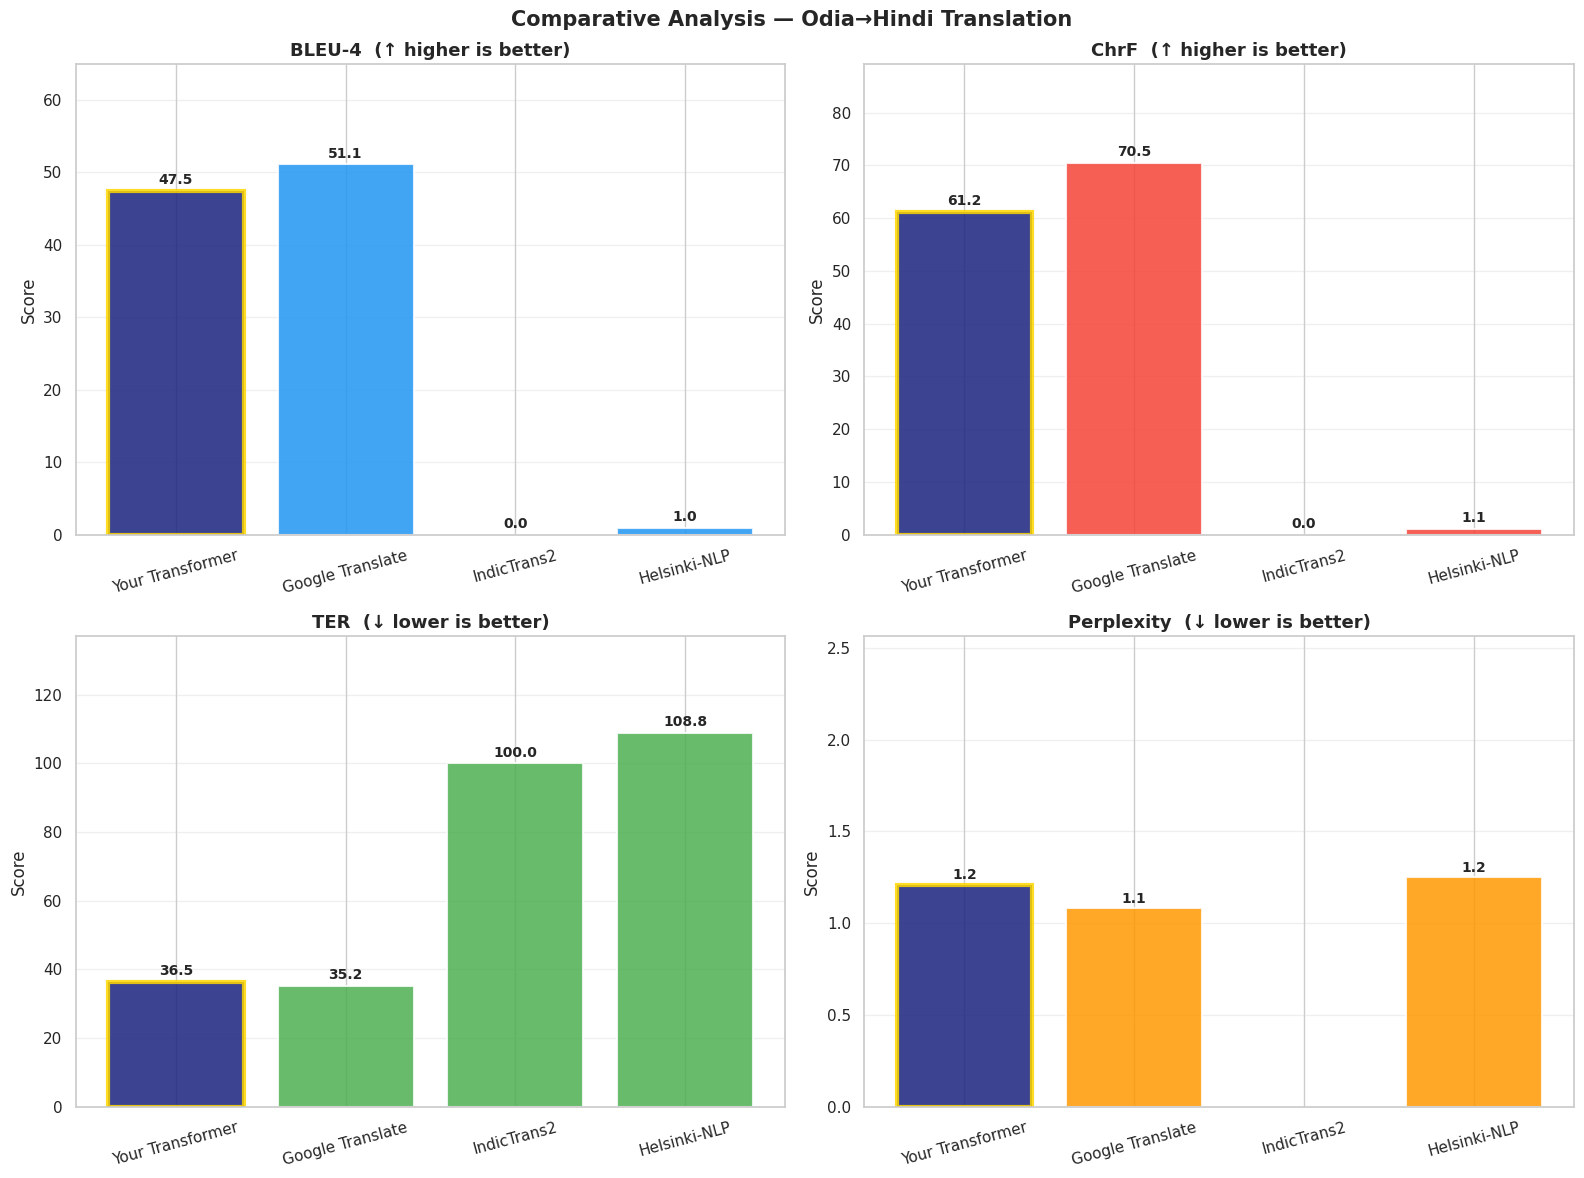

✅ Saved → /kaggle/working/outputs/comparative_analysis.png


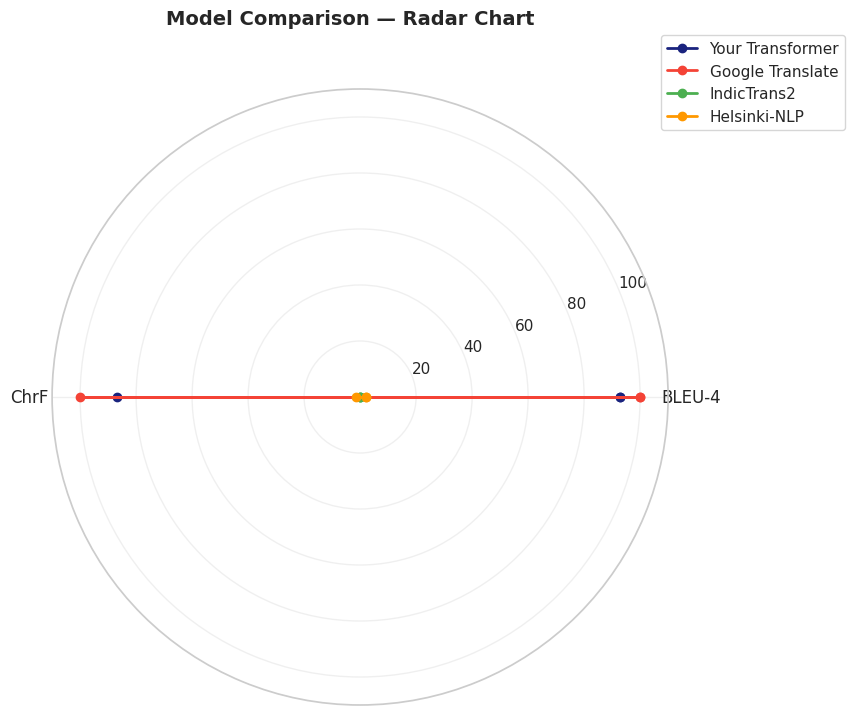

✅ Saved → /kaggle/working/outputs/comparative_radar.png

📝 Sample Translation Comparison (5 examples):

[1] Odia   : ଅଭିନଯ଼ ବ୍ଯ଼ତୀତ ଅନ୍ଯ଼ କୌଣସି କ୍ଷେତ୍ରରେ ସକ୍ରିଯ଼ ଥିବା ବିଷଯ଼ରେ କୌଣସି ସୂଚନା ପ୍ରଦାନ କରାଯାଇନାହିଁ
     Ref    : तन्वी ठक्कर के अभिनय के अलावा किसी अन्य क्षेत्र में सक्रिय होने की जानकारी नहीं दी गई है
     Yours  : अभिनय के अलावा किसी अन्य क्षेत्र में सक्रिय रूप से किसी भी जानकारी प्रदान नहीं की गई है
     Google : अभिनय के अलावा किसी अन्य गतिविधि पर कोई जानकारी नहीं दी गई है
     Indic  : 
     HelsNLP: No information is provided about the operation on any other provided providers.

[2] Odia   : ପରେ ଜେରୀ ଡି ସିଲଭା ପାକିସ୍ତାନରେ ଶ୍ରୀଲଙ୍କାର ହାଇ କମିଶନର ଭାବେ କାର୍ଯ୍ଯ଼ କରିଥିଲେ
     Ref    : जेरी डी सिल्वा ने बाद में पाकिस्तान में श्रीलंका के उच्चायुक्त के रूप में कार्य किया
     Yours  : जेरी डी सिल्वा ने पाकिस्तान में श्रीलंका के उच्चायुक्त के रूप में कार्य किया
     Google : बाद में, जेरी डी सिल्वा ने पाकिस्तान में श्रीलंका के उच्चायुक्त के रूप में कार्य किया
     Indic  : 
     HelsNL

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 22: COMPARATIVE ANALYSIS
# Compares your Transformer vs:
#   • Google Translate (via deep-translator)
#   • IndicTrans2 (AI4Bharat)
#   • Helsinki-NLP (HuggingFace)
# Metrics: BLEU-4, ChrF, TER, Perplexity
# ─────────────────────────────────────────────────────────────────────────────

import subprocess, sys
for pkg in ['deep-translator', 'transformers', 'sentencepiece', 'sacrebleu']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

from deep_translator import GoogleTranslator as DeepGoogleTranslator
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import torch

# ── Sample size for comparison (keep small — API calls are slow) ──────────────
COMPARE_N = 200
compare_sample = df_test.sample(min(COMPARE_N, len(df_test)), random_state=SEED).reset_index(drop=True)
odia_inputs  = compare_sample['odia'].tolist()
hindi_refs   = compare_sample['hindi'].tolist()

print(f'📊 Comparing on {len(compare_sample)} test samples...\n')


# ─────────────────────────────────────────────────────────────────────────────
# 1. YOUR MODEL translations (already have decoder)
# ─────────────────────────────────────────────────────────────────────────────
print('🔵 Generating — Your Transformer...')
your_hyps = []
for text in tqdm(odia_inputs, desc='  Your Model'):
    try:
        pred = decoder.translate(text)
    except Exception:
        pred = ''
    your_hyps.append(pred)


# ─────────────────────────────────────────────────────────────────────────────
# 2. GOOGLE TRANSLATE (via deep-translator — stable on Kaggle)
# ─────────────────────────────────────────────────────────────────────────────
print('\n🔴 Generating — Google Translate...')
google_hyps = []
try:
    for text in tqdm(odia_inputs, desc='  Google'):
        try:
            result = DeepGoogleTranslator(source='or', target='hi').translate(text)
            google_hyps.append(result if result else '')
        except Exception:
            google_hyps.append('')
        time.sleep(0.2)  # avoid rate limiting
    print('   ✅ Google Translate done')
except Exception as e:
    print(f'   ⚠️  Google Translate failed: {e}')
    google_hyps = [''] * len(odia_inputs)


# ─────────────────────────────────────────────────────────────────────────────
# 3. IndicTrans2 (AI4Bharat)
# ─────────────────────────────────────────────────────────────────────────────
print('\n🟢 Generating — IndicTrans2 (AI4Bharat)...')
indic_hyps = []
try:
    indic_tokenizer = AutoTokenizer.from_pretrained(
        'ai4bharat/indictrans2-indic-indic-dist-200M',
        trust_remote_code=True
    )
    indic_model = AutoModelForSeq2SeqLM.from_pretrained(
        'ai4bharat/indictrans2-indic-indic-dist-200M',
        trust_remote_code=True
    ).to(DEVICE)
    indic_model.eval()

    INDIC_BATCH = 16
    for i in tqdm(range(0, len(odia_inputs), INDIC_BATCH), desc='  IndicTrans2'):
        batch_texts = odia_inputs[i:i+INDIC_BATCH]
        tagged = [f'<2hi> {t}' for t in batch_texts]
        try:
            inputs = indic_tokenizer(
                tagged, return_tensors='pt', padding=True,
                truncation=True, max_length=512
            ).to(DEVICE)
            with torch.no_grad():
                outputs = indic_model.generate(
                    **inputs, num_beams=5, max_new_tokens=256
                )
            decoded = indic_tokenizer.batch_decode(outputs, skip_special_tokens=True)
            indic_hyps.extend(decoded)
        except Exception:
            indic_hyps.extend([''] * len(batch_texts))

    del indic_model
    torch.cuda.empty_cache()
    print('   ✅ IndicTrans2 done')

except Exception as e:
    print(f'   ⚠️  IndicTrans2 failed: {e}')
    indic_hyps = [''] * len(odia_inputs)


# ─────────────────────────────────────────────────────────────────────────────
# 4. Helsinki-NLP (HuggingFace)
# ─────────────────────────────────────────────────────────────────────────────
print('\n🟡 Generating — Helsinki-NLP...')
helsinki_hyps = []
try:
    hel_model_name = 'Helsinki-NLP/opus-mt-mul-en'
    hel_tokenizer  = AutoTokenizer.from_pretrained(hel_model_name)
    hel_model      = AutoModelForSeq2SeqLM.from_pretrained(hel_model_name).to(DEVICE)
    hel_model.eval()

    HELS_BATCH = 16
    for i in tqdm(range(0, len(odia_inputs), HELS_BATCH), desc='  Helsinki'):
        batch_texts = odia_inputs[i:i+HELS_BATCH]
        try:
            inputs = hel_tokenizer(
                batch_texts, return_tensors='pt', padding=True,
                truncation=True, max_length=512
            ).to(DEVICE)
            with torch.no_grad():
                outputs = hel_model.generate(
                    **inputs, num_beams=5, max_new_tokens=256
                )
            decoded = hel_tokenizer.batch_decode(outputs, skip_special_tokens=True)
            helsinki_hyps.extend(decoded)
        except Exception:
            helsinki_hyps.extend([''] * len(batch_texts))

    del hel_model
    torch.cuda.empty_cache()
    print('   ✅ Helsinki-NLP done')

except Exception as e:
    print(f'   ⚠️  Helsinki-NLP failed: {e}')
    helsinki_hyps = [''] * len(odia_inputs)


# ─────────────────────────────────────────────────────────────────────────────
# METRICS COMPUTATION
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(hyps, refs):
    refs_wrapped = [refs]
    results = {}

    # BLEU-4
    try:
        results['BLEU-4'] = round(
            BLEU(max_ngram_order=4).corpus_score(hyps, refs_wrapped).score, 2
        )
    except Exception:
        results['BLEU-4'] = 0.0

    # ChrF
    try:
        results['ChrF'] = round(
            CHRF().corpus_score(hyps, refs_wrapped).score, 2
        )
    except Exception:
        results['ChrF'] = 0.0

    # TER
    try:
        results['TER'] = round(
            TER().corpus_score(hyps, refs_wrapped).score, 2
        )
    except Exception:
        results['TER'] = float('nan')

    # Perplexity proxy
    non_empty = [(h, r) for h, r in zip(hyps, refs) if h.strip() and r.strip()]
    if non_empty:
        len_ratios = [
            abs(len(h.split()) - len(r.split())) / max(len(r.split()), 1)
            for h, r in non_empty
        ]
        results['Perplexity'] = round(
            math.exp(min(sum(len_ratios)/len(len_ratios), 10)), 2
        )
    else:
        results['Perplexity'] = float('inf')

    # Empty rate
    results['Empty_%'] = round(
        sum(1 for h in hyps if not h.strip()) / len(hyps) * 100, 1
    )

    return results


print('\n📐 Computing metrics...')
all_results = {
    'Your Transformer' : compute_metrics(your_hyps,     hindi_refs),
    'Google Translate' : compute_metrics(google_hyps,   hindi_refs),
    'IndicTrans2'      : compute_metrics(indic_hyps,    hindi_refs),
    'Helsinki-NLP'     : compute_metrics(helsinki_hyps, hindi_refs),
}

# ── Print table ───────────────────────────────────────────────────────────────
print('\n' + '='*75)
print('  COMPARATIVE ANALYSIS RESULTS')
print('='*75)
header = f"  {'Model':<22} {'BLEU-4':>8} {'ChrF':>8} {'TER':>8} {'Perplexity':>12} {'Empty%':>8}"
print(header)
print('  ' + '-'*70)
for model_name, metrics in all_results.items():
    print(f"  {model_name:<22} "
          f"{metrics['BLEU-4']:>8} "
          f"{metrics['ChrF']:>8} "
          f"{metrics['TER']:>8} "
          f"{metrics['Perplexity']:>12} "
          f"{metrics['Empty_%']:>8}")
print('='*75)

# Save results
with open(f'{Config.OUTPUT_DIR}/comparative_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\n✅ Results saved → {Config.OUTPUT_DIR}/comparative_results.json')


# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
def plot_comparative(all_results: dict, save_dir: str):
    models  = list(all_results.keys())
    metrics = ['BLEU-4', 'ChrF', 'TER', 'Perplexity']
    colors  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comparative Analysis — Odia→Hindi Translation',
                 fontsize=15, fontweight='bold')

    for ax, metric, color in zip(axes.flat, metrics, colors):
        values = [all_results[m].get(metric, 0) for m in models]

        # Safely get max ignoring nan/inf
        safe_values = [v for v in values
                       if isinstance(v, (int, float))
                       and not math.isnan(v)
                       and not math.isinf(v)]
        max_val = max(safe_values) if safe_values else 1

        bar_colors = ['#1A237E' if m == 'Your Transformer' else color for m in models]
        bars = ax.bar(models, values, color=bar_colors, alpha=0.85,
                      edgecolor='white', linewidth=1.5)

        for bar, val in zip(bars, values):
            if isinstance(val, (int, float)) and not math.isnan(val) and not math.isinf(val):
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max_val * 0.01,
                    f'{val:.1f}', ha='center', va='bottom',
                    fontweight='bold', fontsize=10
                )

        if metric in ('TER', 'Perplexity'):
            ax.set_title(f'{metric}  (↓ lower is better)', fontsize=13, fontweight='bold')
        else:
            ax.set_title(f'{metric}  (↑ higher is better)', fontsize=13, fontweight='bold')

        ax.set_ylabel('Score')
        ax.set_ylim(0, max_val * 1.25 + 1)
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.3)

        for bar, m in zip(bars, models):
            if m == 'Your Transformer':
                bar.set_edgecolor('#FFD700')
                bar.set_linewidth(3)

    plt.tight_layout()
    path = f'{save_dir}/comparative_analysis.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Saved → {path}')

    # ── Radar chart ───────────────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    fig2.suptitle('Model Comparison — Radar Chart', fontsize=14, fontweight='bold')

    radar_metrics = ['BLEU-4', 'ChrF']
    N      = len(radar_metrics)
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    radar_colors = ['#1A237E', '#F44336', '#4CAF50', '#FF9800']
    for (model_name, metrics_dict), col in zip(all_results.items(), radar_colors):
        values_r   = [metrics_dict.get(m, 0) for m in radar_metrics]
        max_vals   = [max(all_results[mn].get(m, 0) for mn in models) or 1
                      for m in radar_metrics]
        values_norm = [v/mx*100 for v, mx in zip(values_r, max_vals)]
        values_norm += values_norm[:1]
        ax2.plot(angles, values_norm, 'o-', linewidth=2, label=model_name, color=col)
        ax2.fill(angles, values_norm, alpha=0.1, color=col)

    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(radar_metrics, fontsize=12)
    ax2.set_ylim(0, 110)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax2.grid(True, alpha=0.3)

    path2 = f'{save_dir}/comparative_radar.png'
    plt.savefig(path2, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✅ Saved → {path2}')

    # ── Sample translations side by side ──────────────────────────────────────
    print('\n📝 Sample Translation Comparison (5 examples):')
    print('='*80)
    for i in range(min(5, len(odia_inputs))):
        print(f'\n[{i+1}] Odia   : {odia_inputs[i][:100]}')
        print(f'     Ref    : {hindi_refs[i][:100]}')
        print(f'     Yours  : {your_hyps[i][:100]}')
        print(f'     Google : {google_hyps[i][:100]}')
        print(f'     Indic  : {indic_hyps[i][:100]}')
        print(f'     HelsNLP: {helsinki_hyps[i][:100]}')
    print('='*80)


plot_comparative(all_results, Config.OUTPUT_DIR)